In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
import dtreeviz
import yellowbrick.model_selection as ms
from yellowbrick import classifier

In [2]:
path = "../../data/tested.csv"

df = pd.read_csv(path)

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.shape

(418, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB


In [6]:
df['Parch'].value_counts()

Parch
0    324
1     52
2     33
3      3
4      2
9      2
6      1
5      1
Name: count, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
df.columns = df.columns.str.lower()

In [10]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("cat", cat_pipeline, ['pclass', 'sex', 'sibsp', 'parch', 'embarked']), 
    ("other", SimpleImputer(strategy="mean"), ["fare","age"])
], remainder="passthrough")

X, y = df[['pclass','sex','age','sibsp','parch','fare','embarked']], df[['survived']]
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

In [11]:
x_train_transformed = preprocessing.fit_transform(x_train)
x_test_transformed = preprocessing.transform(x_test)

In [12]:
xg_oob = xgb.XGBClassifier()
xg_oob.fit(x_train_transformed, y_train)
xg_oob.score(x_test_transformed, y_test)

1.0

In [13]:
xg2 = xgb.XGBClassifier(max_depth=2, n_estimators=2)
xg2.fit(x_train_transformed, y_train)
xg2.score(x_test_transformed, y_test)

1.0

Visualising trees inside the model

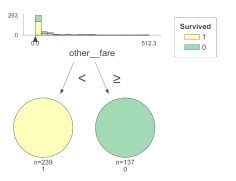

In [14]:
viz = dtreeviz.model(xg2, X_train = x_train_transformed, y_train = y_train['survived'].values, target_name='Survived', feature_names=preprocessing.get_feature_names_out().tolist(), class_names=[1,0], tree_index=0)
viz.view(depth_range_to_display=[0,2])

the fare amount was an important feature in this case

trying a different dataset

In [15]:
path = "../../data/Teen_Mental_Health_Dataset.csv"

df = pd.read_csv(path)

In [16]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [17]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [18]:
df = df.drop(columns=['stress_level','anxiety_level'])

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(sparse_output=False, handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("cat", cat_pipeline, ['platform_usage', 'gender', 'social_interaction_level']),
], remainder="passthrough")

X, y = df[['age', 'gender', 'daily_social_media_hours', 'platform_usage','sleep_hours', 'screen_time_before_sleep', 'academic_performance','physical_activity', 'social_interaction_level']], df['depression_label']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
x_train_transformed = preprocessing.fit_transform(x_train)
x_test_transformed = preprocessing.transform(x_test)

In [20]:
xg_oob = xgb.XGBClassifier()
xg_oob.fit(x_train_transformed, y_train)
xg_oob.score(x_test_transformed, y_test)

0.975

In [21]:
xg2 = xgb.XGBClassifier(max_depth=2, n_estimators=2)
xg2.fit(x_train_transformed, y_train)
xg2.score(x_test_transformed, y_test)

0.975

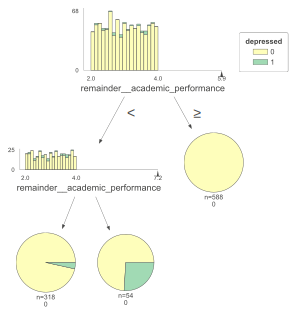

In [22]:
viz = dtreeviz.model(xg2, X_train = x_train_transformed, y_train = y_train, target_name='depressed', feature_names=preprocessing.get_feature_names_out().tolist(), class_names=[0,1], tree_index=1)
viz.view(depth_range_to_display=[0,2])

**early stopping**

In [23]:
xg = xgb.XGBClassifier(early_stopping_rounds=20)
xg.fit(x_train_transformed, y_train, eval_set = [(x_train_transformed, y_train), (x_test_transformed, y_test)])

[0]	validation_0-logloss:0.09138	validation_1-logloss:0.09026
[1]	validation_0-logloss:0.07892	validation_1-logloss:0.08687
[2]	validation_0-logloss:0.06923	validation_1-logloss:0.08726
[3]	validation_0-logloss:0.06160	validation_1-logloss:0.08472
[4]	validation_0-logloss:0.05582	validation_1-logloss:0.08223
[5]	validation_0-logloss:0.05006	validation_1-logloss:0.08132
[6]	validation_0-logloss:0.04549	validation_1-logloss:0.08142
[7]	validation_0-logloss:0.04170	validation_1-logloss:0.08122
[8]	validation_0-logloss:0.03750	validation_1-logloss:0.08235
[9]	validation_0-logloss:0.03470	validation_1-logloss:0.08273
[10]	validation_0-logloss:0.03227	validation_1-logloss:0.08237
[11]	validation_0-logloss:0.03061	validation_1-logloss:0.08318
[12]	validation_0-logloss:0.02827	validation_1-logloss:0.08560
[13]	validation_0-logloss:0.02629	validation_1-logloss:0.08435
[14]	validation_0-logloss:0.02503	validation_1-logloss:0.08535
[15]	validation_0-logloss:0.02403	validation_1-logloss:0.08640
[1

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

model - builds trees upto the set number of trees(default is 100 trees). But if performance has not improved for 20 trees (early stopping rounds trees), then stop

plotting tree performance

- the evals_result method will return a data structure containing the results from the evaluation set.

In [24]:
results = xg.evals_result()

In [25]:
results

{'validation_0': OrderedDict([('logloss',
               [0.09137531187540542,
                0.07891822257855287,
                0.06923428326457118,
                0.06160361816097672,
                0.05582150830305181,
                0.05006463489165374,
                0.04548501431612142,
                0.04169969643601992,
                0.03750332047056872,
                0.03470073038479313,
                0.03227104225091656,
                0.03060613561234883,
                0.02826866185047644,
                0.02629198493753696,
                0.02502661900386253,
                0.02403190616775343,
                0.02258133243425012,
                0.02129990714226248,
                0.02066949177096831,
                0.01980537354038461,
                0.01893143108715473,
                0.01824390504913632,
                0.01758898113691127,
                0.01689220058324281,
                0.01626078519169217,
                0.015584649210995

plot the data and visualise what happens when we add more trees

<Axes: >

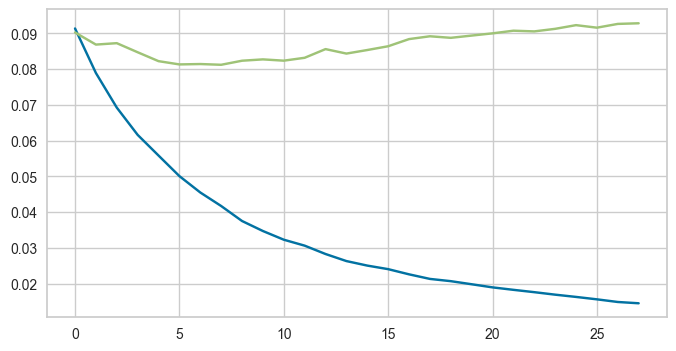

In [26]:
fig, ax = plt.subplots(figsize=(8,4))
plot_df = pd.DataFrame({
    'training': results['validation_0']['logloss'],
    'testing': results['validation_1']['logloss']
})
plot_df['training'].plot(kind='line', ax=ax)
plot_df['testing'].plot(kind='line', ax=ax)

best number of trees seems to be six

In [27]:
xg6 = xgb.XGBClassifier(n_estimators=6)
xg6.fit(x_train_transformed, y_train, eval_set = [(x_train_transformed, y_train),(x_test_transformed, y_test)])
xg6.score(x_test_transformed, y_test)

[0]	validation_0-logloss:0.09138	validation_1-logloss:0.09026
[1]	validation_0-logloss:0.07892	validation_1-logloss:0.08687
[2]	validation_0-logloss:0.06923	validation_1-logloss:0.08726
[3]	validation_0-logloss:0.06160	validation_1-logloss:0.08472
[4]	validation_0-logloss:0.05582	validation_1-logloss:0.08223
[5]	validation_0-logloss:0.05006	validation_1-logloss:0.08132


0.975

found the optimal number of trees (estimators), by looking at the original train and eval curves...used this optimal number and got the same accuracy

finally - look at the model that creates exactly 100 trees. score ideally should be worse than the optimal number of trees..

In [28]:
xg_no_es = xgb.XGBClassifier()
xg_no_es.fit(x_train_transformed, y_train)
xg_no_es.score(x_test_transformed, y_test)

0.975

not an ideally dataset perhaps, but, early stopping rounds helps prevent overfitting..
- different eval_metrics:
- some of the most common eval_metrics for classification are:
  - Log loss: log loss measures a model's negative log likelihood performance that predicts a given class probability. it penalizes incorrect predictions more heavily than correct ones
  - area under the curve: auc is a measure of the performance of a binary classification model. it is the area under a receiver operating characteristic curve
  - accuracy: percent of correct predictions

In [29]:
# setting the eval_metric to error, which is the accuracy:
xg_err = xgb.XGBClassifier(early_stopping_rounds=6, eval_metric="error")
xg_err.fit(x_train_transformed, y_train, eval_set=[(x_train_transformed, y_train),(x_test_transformed, y_test)])

[0]	validation_0-error:0.02604	validation_1-error:0.02500
[1]	validation_0-error:0.02604	validation_1-error:0.02500
[2]	validation_0-error:0.02604	validation_1-error:0.02500
[3]	validation_0-error:0.02604	validation_1-error:0.02500
[4]	validation_0-error:0.02604	validation_1-error:0.02500
[5]	validation_0-error:0.02604	validation_1-error:0.02500
[6]	validation_0-error:0.02500	validation_1-error:0.02500


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",6
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [30]:
xg_err.score(x_test_transformed, y_test)

0.975

**XGBoost Hyperparameters**

- max_depth: controls how deep each decision tree is allowed to grow (higher max depth, high complexity and model is then more prone to overfitting)
- max_leaves: controls the maximum number of leaf nodes each xgboost tree is allowed to have (a leaf is an endpoint of the tree where the final prediction value is stored) | 
  - max depth limits the height of the tree whereas max_leaves limits the number of final prediction groups
- min_child_weight: min_child_weight controls how much evidence xgboost needs before it is allowed to create a child node/leaf
  - min_child_weight asks: after making a split (splitting a node to children - do the child nodes contain enough total weight to be trusted)
  - if not, xgboost rejects the split
    - a low value: means the xgboost model is willing to create small, specific leaves | more splits, more complex trees, and higher overfitting risk
    - higher value: only create a leaf if there is enough data/evidence behind it | fewer splits, simpler trees, and higher underfitting risk
    - analogous to min_samples_leaf in simple decision trees
  - grow_policy = controls how xgboost grows each tree | it ansswers when xgboost is building a tree, which node should it split next |
    - there are 2 options: grow_policy="depthwise" and grow_policy="lossguide" | 
    - growpolicy="depthwise": grows the tree level by level | xgboost says split nodes across the current depth before going deeper
    - with depthwise, the main complexity control is usually max_depth
    - e.g. XGBClassifier(tree_method="hist", grow_policy="depthwise", max_depth=4)
      - depthwise: more stable | less likely to create weird one-sided trees | easier to reason about with maxdepth, good for smaller/medium sized datasets | good when u want controlled tree shapes
    
    - growpolicy="lossguide"
      - lossguide grows the tree by repeatedly splitting the node that gives the biggest loss reduction | it asks which available split would reduce the objective/loss the most right now
      - then split that node evn if that makes the tree uneven
      - this can create an unbalanced tree
      - main complexity control with loss guide is max_leaves
      - e.g. XGBClassifier(tree_method="hist",grow_policy="lossguide",max_leaves=31, max_depth=0)
    
  - tree_method: controls the algorithm that xgboost uses to find splits when building each tree | doesn't control overfitting but mainly controls how xgboost searches for the best split
    - tree_method: exact (checks all possible split candidates) most literal method| tree_method="approx" uses an approximate split-finding algorithm - instead of checking every possible threshold exactly, it uses an approximation strategy based on quantile sketching and gradient histograms | tree_method="hist" -> xgboost's fast histogram based tree builder | instead of using every raw numeric value directly, it bins feature values into a limited number of buckets. then searches splits over bins not every individual value 

  - sampling hyperparams:
    - colsample_bytree: subsample columns at each tree | colsample_bylevel: subsample cols at each level | colsample_bynode: subsample columns at each node split  (from the tree columns)
    - subsample: sample portions of the training data before each boosting round
    - sampling_method: the sampling method to use. 
  - n_estimators:the number of estimators | eval_metric - metric for evaluating val data
  - objective: learning objective
  - learning_rate
  - gamma: prune to remove splits that do not meet the given value
  - reg_alpha: L1 regularization | reg_lambda: L2 regularization

 - Imbalanced data hyperparameters:
   - scale_pos_weight: controls how much extra importance xgboost gives to the positive class during training | scale_pos_weight = number of negative examples/number of positive examples
   - scale pos weight affects the class labelled as 1 | e.g. example with class 0: 9k examples, class 1: 1k examples, scale_pos_weight = 9,| give positive-class examples about 9x more importance in the training data... | scale_pos_weight of 1 means do not upweight the positive class | compute it from the training set

   - sample_weight: give individual training rows their own importance during training | sample_weight: (instance weights) 
     - normally every row counts equally: (each row weight = 1) | sample weight: class imbalance, newer and recent data that matters more | 

 - max_delta_step: safety brake on how big each tree's leaf update is allowed to be | each tree is allowed to steer th emodel | without max_delta_step: model tuning not conservative and can sway a lot depending on the trees. | good range to try: [0, 1, 2, 5, 10] | but would try it last after tuning other hyperparams


**Hyperopt:**

In [33]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import accuracy_score, roc_auc_score
from typing import Any, Dict, Union

/Users/blaise/Documents/ML/Machine-Learning-and-Big-Data-Analytics/venv2/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [34]:
def hyperparameter_tuning(space:Dict[str, Union[float, int]], X_train:pd.DataFrame, y_train:pd.Series, X_test:pd.DataFrame, y_test:pd.Series, early_stopping_rounds:int=50, metric:callable=accuracy_score) -> Dict[str, Any]:
    """
        Perform hyperparameter tuning. This function takes a dictionary of hyperparameters, training and test data and optional values for early stopping rounds
        returns a dictionary with the loss and model resulting from the tuning process
        the model is trained using the training data and evaluated on the test data. loss is computed as the negative of the accuracy score

    """
    int_vals = ['max_depth', 'reg_alpha']
    space = {k: (int(val)) if k in int_vals else val for k,val in space.items()}
    space['early_stopping_rounds'] = early_stopping_rounds
    model = xgb.XGBClassifier(**space)

    evaluation = [(X_train, y_train), (X_test, y_test)]
    model.fit(X_train, y_train, eval_set=evaluation, verbose=False)
    pred = model.predict(X_test)
    score = metric(y_test, pred)
    return {"loss":-score, "status": STATUS_OK, "model": model}


options = {
    "max_depth": hp.quniform("max_depth", 1, 8, 1), # reg
    "min_child_weight": hp.loguniform("min_child_weight", -2, 3),  # reg
    "subsample": hp.uniform("subsample", 0.5, 1), # reg
    "colsample_bytree": hp.uniform("colsample_bytree", 0.5, 1), # reg
    "reg_alpha": hp.uniform("reg_alpha", 0, 10),  # regularization
    "reg_lambda": hp.uniform("reg_lambda", 1, 10), # regularization
    "gamma": hp.loguniform("gamma", -10, 10), # regularization
    "learning_rate": hp.loguniform("learning_rate", -7, 0), # boosting
    "random_state": 42
}

trials = Trials()
best = fmin(fn=lambda space: hyperparameter_tuning(space, x_train_transformed, y_train, x_test_transformed, y_test), space=options, algo=tpe.suggest, max_evals=50, trials=trials)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 50/50 [00:02<00:00, 17.14trial/s, best loss: -0.975]


In [35]:
best

{'colsample_bytree': 0.5203317230460578,
 'gamma': 0.01964728683639212,
 'learning_rate': 0.008012955506215072,
 'max_depth': 6.0,
 'min_child_weight': 3.5234480868599536,
 'reg_alpha': 3.466246289659348,
 'reg_lambda': 5.962834304267915,
 'subsample': 0.7692922903496023}

In [36]:
# now we can train with the best params
best_params = {k: int(val) if k in ["max_depth"] else val for k,val in best.items()}
xg_ex = xgb.XGBClassifier(**best_params, early_stopping_rounds=50, n_estimators=500)
xg_ex.fit(x_train_transformed, y_train, eval_set=[(x_train_transformed, y_train), (x_test_transformed, y_test)], verbose=100)

[0]	validation_0-logloss:0.12060	validation_1-logloss:0.11690
[100]	validation_0-logloss:0.11019	validation_1-logloss:0.10758
[200]	validation_0-logloss:0.10210	validation_1-logloss:0.10056
[300]	validation_0-logloss:0.09687	validation_1-logloss:0.09651
[400]	validation_0-logloss:0.09244	validation_1-logloss:0.09317
[499]	validation_0-logloss:0.08851	validation_1-logloss:0.09074


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5203317230460578
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [37]:
xg_ex.score(x_test_transformed, y_test)

0.975

**defining parameter distributions:**
- choice: specify a discrete set of values for a categorical hyperparameter  

In [38]:
from hyperopt import hp, pyll

In [39]:
pyll.stochastic.sample(hp.choice('value', ['a', 'b', 'c']))

'b'

to generate a random value from a list of possible values ['a','b','c'] with probabilities [0.05, 0.9, 0.05] - use the choice function

In [40]:
pyll.stochastic.sample(hp.pchoice('value', [(.05, 'a'), (.9, 'b'), (.05,'c')]))

'b'

the uniform function:
- can specify a uniform distribution over a continous range of values. takes 2 values the min and max of the uniform distribution and returnd a floating point value within this range. 

In [41]:
pyll.stochastic.sample(hp.uniform('value', 0, 1))

0.8715149026790028

In [42]:
uniform_vals = [pyll.stochastic.sample(hp.uniform('value', 0, 1)) for _ in range(10000)]

(array([1005.,  979., 1019.,  996.,  969.,  995.,  996., 1037.,  997.,
        1007.]),
 array([1.73627337e-04, 1.00154085e-01, 2.00134543e-01, 3.00115001e-01,
        4.00095459e-01, 5.00075916e-01, 6.00056374e-01, 7.00036832e-01,
        8.00017290e-01, 8.99997748e-01, 9.99978205e-01]),
 <BarContainer object of 10 artists>)

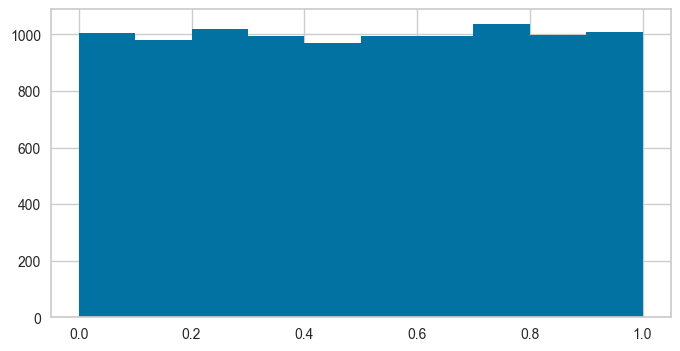

In [43]:
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(uniform_vals)

the loguniform fn can specify a log-uniform distribution oer a continuous range. takes 2 arguments: min and max of the log unofrm distro and trturns a random floating point value within this range on a logarithmic scale. 
- loguniform scaling -> multiplicative effect: mostly suitable for params such as: learning_rate, reg_alpha, reg_lambda, min_child_weight, gamma

**Exploring the trials:**
- the trial object from the hyperopt search has data about the hyperparameter optimization

**Stepwise tuning:**
- another option for tuning fast is to use stepwise hyperparam tuning with hyperopt...group params that function the same way together, tune for them, move to the next batch of params, all whilst preserving the model's learned params

In [44]:
params = {"random_state": 42}

rounds = [{"max_depth": hp.quniform("max_depth", 1, 8, 1), "min_child_weight": hp.loguniform("min_child_weight", -2, 3)},\
          {"subsample": hp.uniform("subsample", 0.5, 1), "colsample_bytree": hp.uniform("colsample_bytree", 0.5, 1)},\
          {"reg_alpha": hp.uniform("reg_alpha", 0, 10), "reg_lambda": hp.uniform("reg_lambda", 1, 10)},\
          {"gamma": hp.loguniform("gamma", -10, 10)},\
          {"learning_rate": hp.loguniform("learning_rate", -7, 0)}]

# 
all_trials = []

for round in rounds:
    params = {**params, **round}
    trials = Trials()
    best = fmin(fn=lambda space:hyperparameter_tuning(space, x_train_transformed, y_train, x_test_transformed, y_test), space=params, algo=tpe.suggest, max_evals=20, trials=trials)

    params = {**params, **best}
    print("Params: ", params)
    print("Best: ",best)
    print("Merge: ", {**params, **best})
    print("\n")
    all_trials.append(trials)

100%|██████████| 20/20 [00:01<00:00, 19.66trial/s, best loss: -0.975]
Params:  {'random_state': 42, 'max_depth': 6.0, 'min_child_weight': 1.05485875449448}
Best:  {'max_depth': 6.0, 'min_child_weight': 1.05485875449448}
Merge:  {'random_state': 42, 'max_depth': 6.0, 'min_child_weight': 1.05485875449448}


100%|██████████| 20/20 [00:01<00:00, 14.79trial/s, best loss: -0.975]
Params:  {'random_state': 42, 'max_depth': 6.0, 'min_child_weight': 1.05485875449448, 'subsample': 0.6092121270514327, 'colsample_bytree': 0.7472875714750746}
Best:  {'colsample_bytree': 0.7472875714750746, 'subsample': 0.6092121270514327}
Merge:  {'random_state': 42, 'max_depth': 6.0, 'min_child_weight': 1.05485875449448, 'subsample': 0.6092121270514327, 'colsample_bytree': 0.7472875714750746}


100%|██████████| 20/20 [00:01<00:00, 13.59trial/s, best loss: -0.975]
Params:  {'random_state': 42, 'max_depth': 6.0, 'min_child_weight': 1.05485875449448, 'subsample': 0.6092121270514327, 'colsample_bytree': 0.747287571475

In [45]:
params

{'random_state': 42,
 'max_depth': 6.0,
 'min_child_weight': 1.05485875449448,
 'subsample': 0.6092121270514327,
 'colsample_bytree': 0.7472875714750746,
 'reg_alpha': 1.1431915196305775,
 'reg_lambda': 9.517648590315522,
 'gamma': 40.038595665775944,
 'learning_rate': 0.004487997988113584}

**feature importance:**
- xgboost also reports feature importance. the .feature_importances_ attribute reports the normalized gain across all the trees when a feature is used.

In [46]:
xgb_def = xgb.XGBClassifier()
xgb_def.fit(x_train_transformed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

- calling model.feature_importances_ spits out a numpy array with one number per input feature. The values are relative importance scores, usually normalised so they sum up to 1.0......
- importance type can be: weight, gain, cover, total_gain, total_cover | all set hyperparams depending on what u initially set as the importance_type when defining the model....default is 'gain'
- this usually means for each feature, how much did splits on this feature improve the model's objective/loss, on average
- A high gain: When XGBoost used this feature to split, that split tended to be useful..... | the gain relates to the average improvement in the model objective from splits using that feature. 

- others:
  - can also get feature importances based on importance types of: weight, cover, total_gain, and total_cover
  - "weight:"=> how many times the feature was used for splitting across the trees (feature used multiple times for splits get higher importance | but this can be misleading as the feature can be used often in weak splits)
  - "cover:"the average amount of training data affected by splits using that feature. (when this feature was used how many observations did those splits touch)
  - "total_gain": the total improvement from all splits using that feature. unlike gain, this is not average gain, it adds up all gains...so a feature used many times can score highly despite it not being so impactful
  - total_cover: total coverage across all splits...again this sums instead of averaging...

- weight = how many times feature was used for splitting
- cover  = average amount of data affected by splits using that feature | not usually in raw 'row_count' values 
- gain   = average improvement in the model objective from splits using that feature

In [47]:
xgb_def.feature_importances_

array([0.10525811, 0.02841969, 0.08814788, 0.06499708, 0.        ,
       0.0212317 , 0.08860514, 0.03663972, 0.05371361, 0.19981195,
       0.15208404, 0.07018404, 0.04492302, 0.04598403], dtype=float32)

<Axes: >

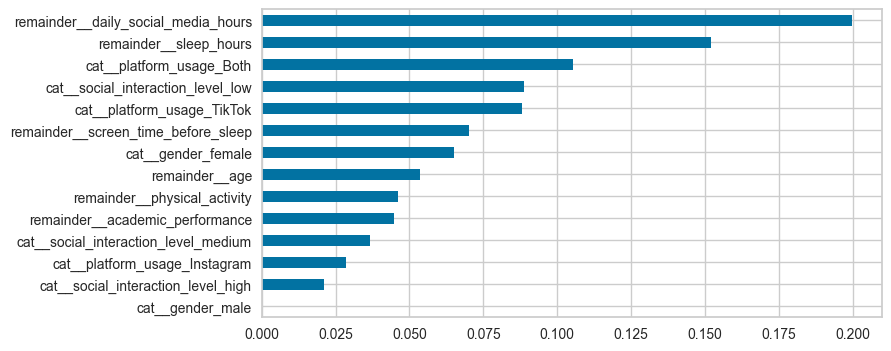

In [48]:
fig, ax = plt.subplots(figsize=(8,4))
pd.Series(xgb_def.feature_importances_, index=preprocessing.get_feature_names_out().tolist()).sort_values().plot.barh(ax=ax)

- can also visualise the feature importance directly from xgboost. the .plot_importance method has an importance_type parameter to change how importance is measured.
- plot_importance has an importance_type parameter to change how importance is being measured. 

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

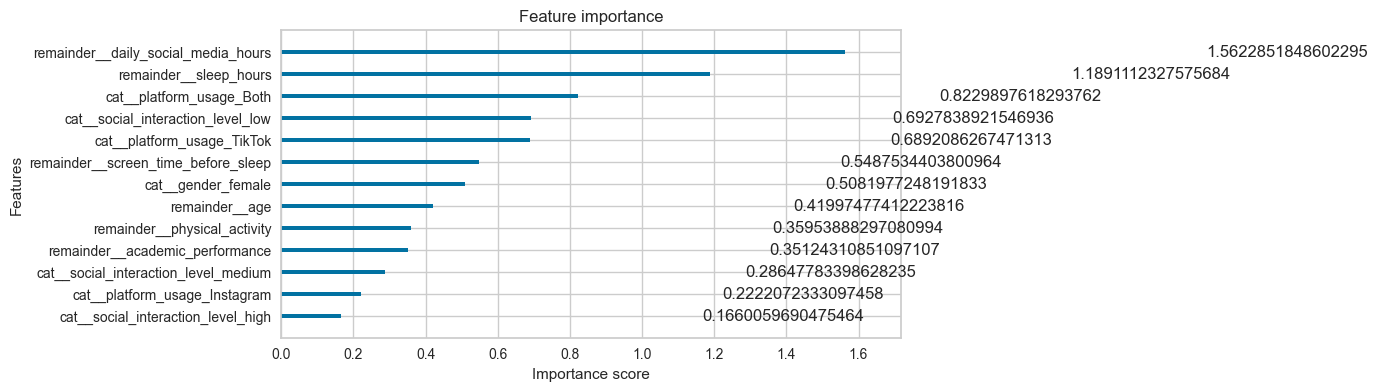

In [49]:
xgb_def.get_booster().feature_names = preprocessing.get_feature_names_out().tolist()
fig, ax = plt.subplots(figsize=(8,4))
xgb.plot_importance(xgb_def, importance_type="gain", ax=ax)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

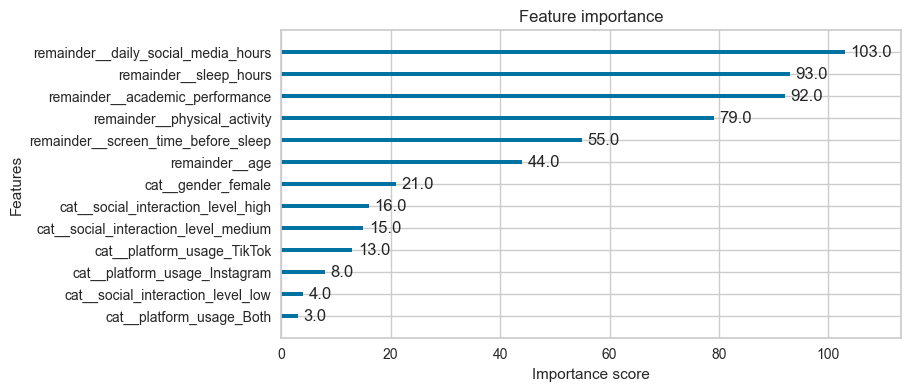

In [50]:
fig, ax = plt.subplots(figsize=(8,4))
xgb.plot_importance(xgb_def, importance_type="weight", ax=ax)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

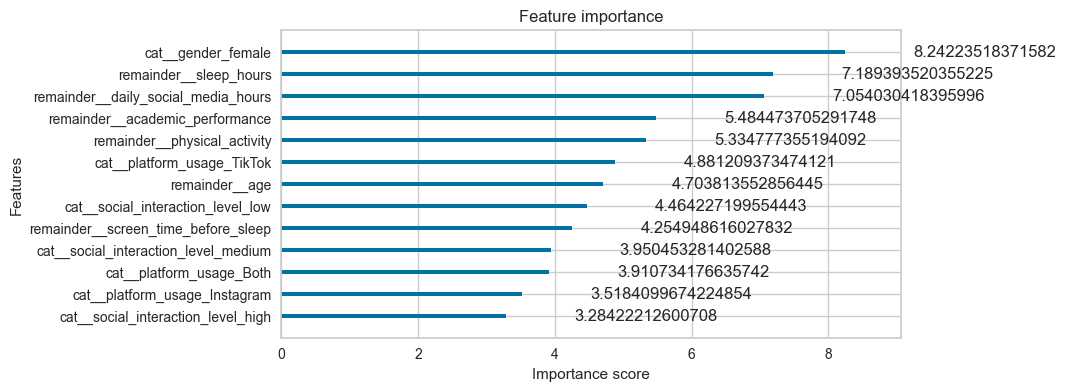

In [51]:
fig, ax = plt.subplots(figsize=(8,4))
xgb.plot_importance(xgb_def, importance_type="cover", ax=ax)

**surrogate models:**
- another way to tease apart the xgboost model is to train a decision tree to its predictions and then explore the interpretable decision tree.

In [52]:
from sklearn import tree

In [53]:
sur_reg_sk = tree.DecisionTreeRegressor(max_depth=4)
sur_reg_sk.fit(pd.DataFrame(x_train_transformed, columns=preprocessing.get_feature_names_out().tolist()), xgb_def.predict_proba(x_train_transformed)[:, 1])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [54]:
tree.export_graphviz(sur_reg_sk, out_file='sur-sk.dot',
feature_names=preprocessing.get_feature_names_out().tolist(), filled=True, rotate=True,
fontname='Roboto Condensed')

- the surrograte tree shown below, helps us understand the decision making of the xgboost model.
- we are using probabilities so :
  - split condition
  - squared_error = how mixed/variable the XGBoost probabilities are inside that node
  - samples = number of rows reaching that node
  - value = average XGBoost predicted probability in that node

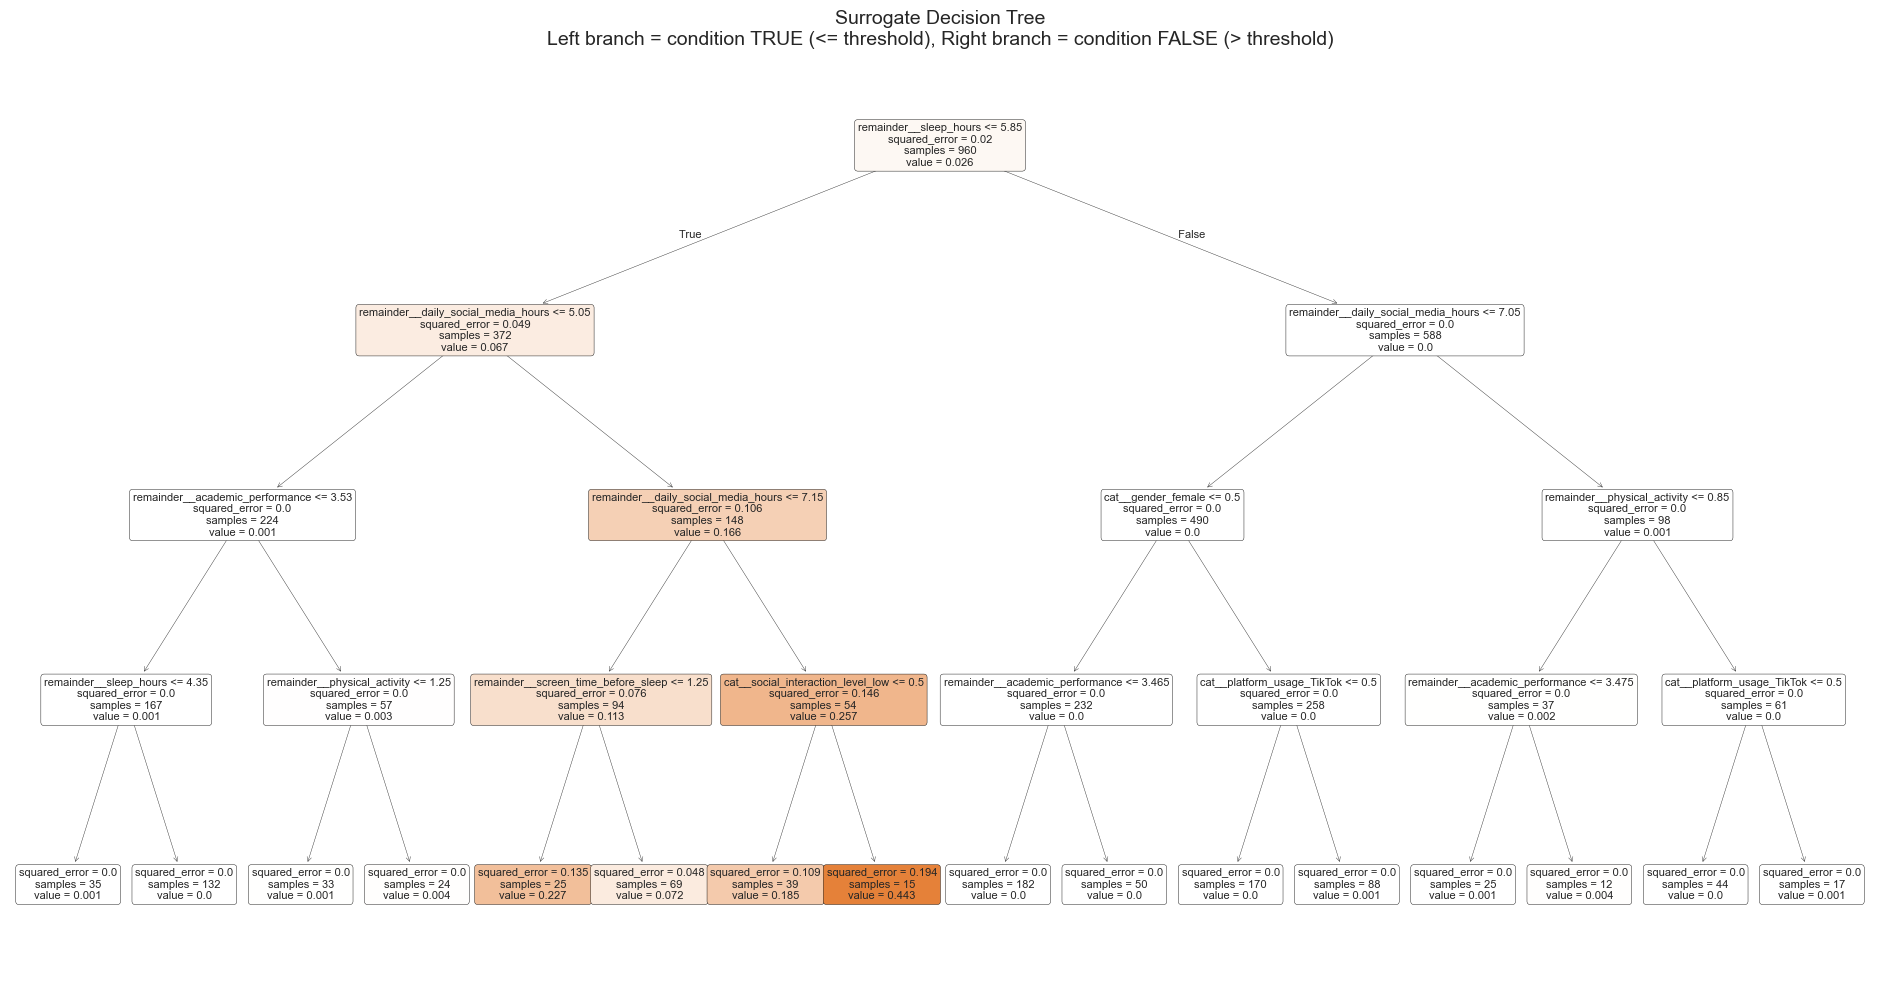

In [55]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(24, 12))

plot_tree(
    sur_reg_sk,
    feature_names=preprocessing.get_feature_names_out().tolist(),
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=8,
    ax=ax
)
ax.set_title(
    "Surrogate Decision Tree\nLeft branch = condition TRUE (<= threshold), Right branch = condition FALSE (> threshold)",
    fontsize=14
)

plt.show()

or as text:

In [ ]:
from sklearn.tree import export_text

rules = export_text(
    sur_reg_sk,
    feature_names=preprocessing.get_feature_names_out().tolist(),
    decimals=3
)

print(rules)

|--- remainder__sleep_hours <= 5.850
|   |--- remainder__daily_social_media_hours <= 5.050
|   |   |--- remainder__academic_performance <= 3.530
|   |   |   |--- remainder__sleep_hours <= 4.350
|   |   |   |   |--- value: [0.001]
|   |   |   |--- remainder__sleep_hours >  4.350
|   |   |   |   |--- value: [0.000]
|   |   |--- remainder__academic_performance >  3.530
|   |   |   |--- remainder__physical_activity <= 1.250
|   |   |   |   |--- value: [0.001]
|   |   |   |--- remainder__physical_activity >  1.250
|   |   |   |   |--- value: [0.004]
|   |--- remainder__daily_social_media_hours >  5.050
|   |   |--- remainder__daily_social_media_hours <= 7.150
|   |   |   |--- remainder__screen_time_before_sleep <= 1.250
|   |   |   |   |--- value: [0.227]
|   |   |   |--- remainder__screen_time_before_sleep >  1.250
|   |   |   |   |--- value: [0.072]
|   |   |--- remainder__daily_social_media_hours >  7.150
|   |   |   |--- cat__social_interaction_level_low <= 0.500
|   |   |   |   |--- va

**XGBFIR (Feature interactions reshaped)**
- define feature interactions, see how they relate to each other and shpw hpw tp find them in XGBoos, and then also introduce interaction constraints
  - **feature interactions:**
    - statisticians say that x1 and x2 interact when the x1 changes are not constant in the change to y but also depend on x2
    - in decision trees, a feature x1 doesn't interact with another feature x2, if x2 is not in the path or if x2 is used the same in each path. otherwise there is an interaction and both features combined to impact the result
- the xgbfir library allows us to find top interactions from our data in an xgboost model. 
  - need the external xgbfir library, as well as the openpyxl library

In [ ]:
import xgbfir

xgbfir.saveXgbFI(xgb_def, feature_names=preprocessing.get_feature_names_out().tolist(), OutputXlsxFile='fir.xlsx')

interpretation of the columns from this:
- Gain: total gain of each feature or feature interaction
- FScore: amount of possible splits taken on a feature or feature interaction (i.e. how many times a feature or interaction appears as a split pattern in the xgboost trees) ..closer in meaning to how many times a feature is used to split
- wFscore: amount to possible splits taken on a feature or interaction, weighted by the probability of the splits to take place | wfscore: how often this feature appears in splits weighted by how much data reachers those paths
- average wfscore: wfscore divided by fscore
- average gain: gain divided by fscore
- expected gain: total gain of each feature or feature interaction weighted by the probability of the gain


---------- summary--------
- FScore            = how often it appears
- wFScore           = how often it appears, weighted by path probability / how often that path is reached
- Gain              = total improvement in objective/loss
- Average wFScore   = wFScore / FScore
- Average Gain      = Gain / FScore
- Expected Gain     = gain weighted by probability of getting that gain
- Average Tree Index = average boosting round/tree number where it appears
- Average Tree Depth = average depth in the tree where it appears


In [ ]:
fir = pd.read_excel("fir.xlsx")
fir.sort_values(by="Average Rank").head().round(1)

,Interaction,Gain,FScore,wFScore,Average wFScore,Average Gain,Expected Gain,Gain Rank,FScore Rank,wFScore Rank,Avg wFScore Rank,Avg Gain Rank,Expected Gain Rank,Average Rank,Average Tree Index,Average Tree Depth
0,remainder__daily_social_media_hours,160.9,103,59.6,0.6,1.6,74.5,1,1,1,2,1,2,1.3,34.4,1.8
1,remainder__sleep_hours,110.6,93,52.0,0.6,1.2,90.5,2,2,2,4,2,1,2.2,36.7,1.7
2,remainder__academic_performance,32.3,92,49.9,0.5,0.4,14.4,3,3,3,5,10,3,4.5,39.3,1.9
4,remainder__physical_activity,28.4,79,45.2,0.6,0.4,9.7,5,4,4,3,9,4,4.8,39.0,1.6
3,remainder__screen_time_before_sleep,30.2,55,23.6,0.4,0.5,8.2,4,5,5,10,6,5,5.8,41.3,2.4


based on the average rank....above table confirms what we had seen from the surrogate model..
- daily social media hours and sleep hours are important features for our model

Need to move to the next sheet to view interactions....
- the interaction depth 1 sheet shows how pairs of columns interact....

In [ ]:
pd.read_excel("fir.xlsx", sheet_name="Interaction Depth 1").iloc[:20]\
                                                           .sort_values(by="Average Rank")\
                                                           .head(10)\
                                                           .round(1)

,Interaction,Gain,FScore,wFScore,Average wFScore,Average Gain,Expected Gain,Gain Rank,FScore Rank,wFScore Rank,Avg wFScore Rank,Avg Gain Rank,Expected Gain Rank,Average Rank,Average Tree Index,Average Tree Depth
0,remainder__daily_social_media_hours|remainder_...,205.8,32,17.8,0.6,6.4,102.7,1,2,1,2,2,1,1.5,29.2,1.7
1,remainder__daily_social_media_hours|remainder_...,48.7,19,10.2,0.5,2.6,18.7,2,6,5,5,5,2,4.2,34.4,2.1
3,remainder__academic_performance|remainder__dai...,33.6,31,16.5,0.5,1.1,14.3,4,3,3,6,25,3,7.3,34.9,2.0
7,remainder__academic_performance|remainder__sle...,20.3,22,11.9,0.5,0.9,9.9,8,4,4,4,27,6,8.8,40.7,2.2
4,remainder__physical_activity|remainder__sleep_...,31.6,38,17.0,0.4,0.8,10.1,5,1,2,19,28,5,10.0,38.2,1.9
2,remainder__daily_social_media_hours|remainder_...,40.1,21,7.7,0.4,1.9,9.8,3,5,7,31,9,7,10.3,39.1,2.2
6,remainder__academic_performance|remainder__aca...,22.3,19,7.8,0.4,1.2,8.5,7,7,6,24,23,8,12.5,25.9,2.4
5,cat__gender_female|remainder__daily_social_med...,27.2,4,2.0,0.5,6.8,12.2,6,29,27,10,1,4,12.8,16.0,2.0
11,cat__gender_female|remainder__sleep_hours,13.4,9,4.3,0.5,1.5,6.2,12,19,16,13,14,9,13.8,20.7,1.9
19,remainder__age|remainder__physical_activity,8.0,14,7.4,0.5,0.6,2.5,20,10,8,7,37,18,16.7,50.6,1.6


In [ ]:
print(pd.read_excel("fir.xlsx", sheet_name="Interaction Depth 1").iloc[:20]\
                                                           .sort_values(by="Average Rank")\
                                                           .head(10)\
                                                           .loc[:,"Interaction"].values)

['remainder__daily_social_media_hours|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__daily_social_media_hours'
 'remainder__academic_performance|remainder__daily_social_media_hours'
 'remainder__academic_performance|remainder__sleep_hours'
 'remainder__physical_activity|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__screen_time_before_sleep'
 'remainder__academic_performance|remainder__academic_performance'
 'cat__gender_female|remainder__daily_social_media_hours'
 'cat__gender_female|remainder__sleep_hours'
 'remainder__age|remainder__physical_activity']


daily social media hours, is often followed by sleep hours...above grouping tells us which features have an impact on each other. ...
- can explore htese further with a correlation heatmap with both pandas and seaborn.
- features showed they interact, we want to see how much they do using a correlation heatmap.. if the correlation between them is high as well then the interaction is linear otherwise its non linear

In [ ]:
pd.DataFrame(x_train_transformed, columns=preprocessing.get_feature_names_out()).corr(method='spearman').style.background_gradient(cmap='RdBu', vmin=-1, vmax=1).format('{:.2f}')

,cat__platform_usage_Both,cat__platform_usage_Instagram,cat__platform_usage_TikTok,cat__gender_female,cat__gender_male,cat__social_interaction_level_high,cat__social_interaction_level_low,cat__social_interaction_level_medium,remainder__age,remainder__daily_social_media_hours,remainder__sleep_hours,remainder__screen_time_before_sleep,remainder__academic_performance,remainder__physical_activity
cat__platform_usage_Both,1.00,-0.51,-0.48,-0.01,0.01,-0.08,-0.00,0.08,0.03,-0.03,0.01,-0.00,-0.03,-0.04
cat__platform_usage_Instagram,-0.51,1.00,-0.51,0.02,-0.02,0.03,-0.05,0.02,-0.02,0.03,-0.02,-0.01,0.03,0.06
cat__platform_usage_TikTok,-0.48,-0.51,1.00,-0.00,0.00,0.05,0.06,-0.10,-0.01,-0.00,0.01,0.02,0.00,-0.02
cat__gender_female,-0.01,0.02,-0.00,1.00,-1.00,0.04,-0.03,-0.01,-0.02,-0.02,0.03,0.01,0.00,-0.03
cat__gender_male,0.01,-0.02,0.00,-1.00,1.00,-0.04,0.03,0.01,0.02,0.02,-0.03,-0.01,-0.00,0.03
cat__social_interaction_level_high,-0.08,0.03,0.05,0.04,-0.04,1.00,-0.48,-0.50,0.06,-0.04,0.01,0.02,-0.00,0.04
cat__social_interaction_level_low,-0.00,-0.05,0.06,-0.03,0.03,-0.48,1.00,-0.52,0.03,-0.00,0.02,-0.02,0.02,-0.03
cat__social_interaction_level_medium,0.08,0.02,-0.10,-0.01,0.01,-0.50,-0.52,1.00,-0.08,0.05,-0.03,-0.01,-0.02,-0.00
remainder__age,0.03,-0.02,-0.01,-0.02,0.02,0.06,0.03,-0.08,1.00,-0.02,0.01,0.06,-0.02,-0.01
remainder__daily_social_media_hours,-0.03,0.03,-0.00,-0.02,0.02,-0.04,-0.00,0.05,-0.02,1.00,0.01,0.04,-0.02,0.00


correlation between daily social media hours and sleep_hours is just 0.01 despite it being the strongest feature-feature interaction...so perhaps the interaction is non linear...

In [ ]:
z = pd.DataFrame(x_train_transformed, columns=preprocessing.get_feature_names_out())
z['depressed'] = y_train
# z['depressed'] = z['depressed'].astype('str')

<Axes: xlabel='remainder__daily_social_media_hours', ylabel='remainder__screen_time_before_sleep'>

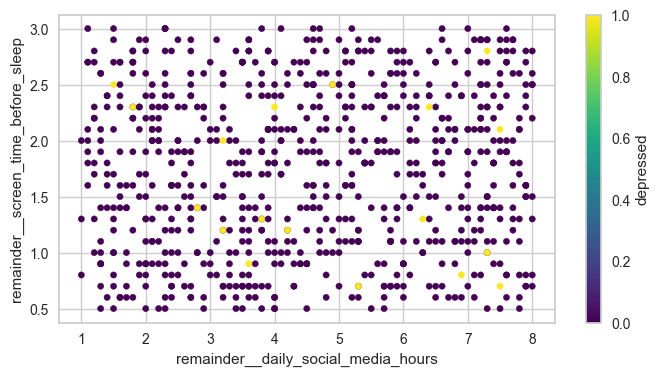

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
z.plot(kind='scatter',ax=ax,x='remainder__daily_social_media_hours', y='remainder__sleep_hours', c='depressed',cmap='viridis')

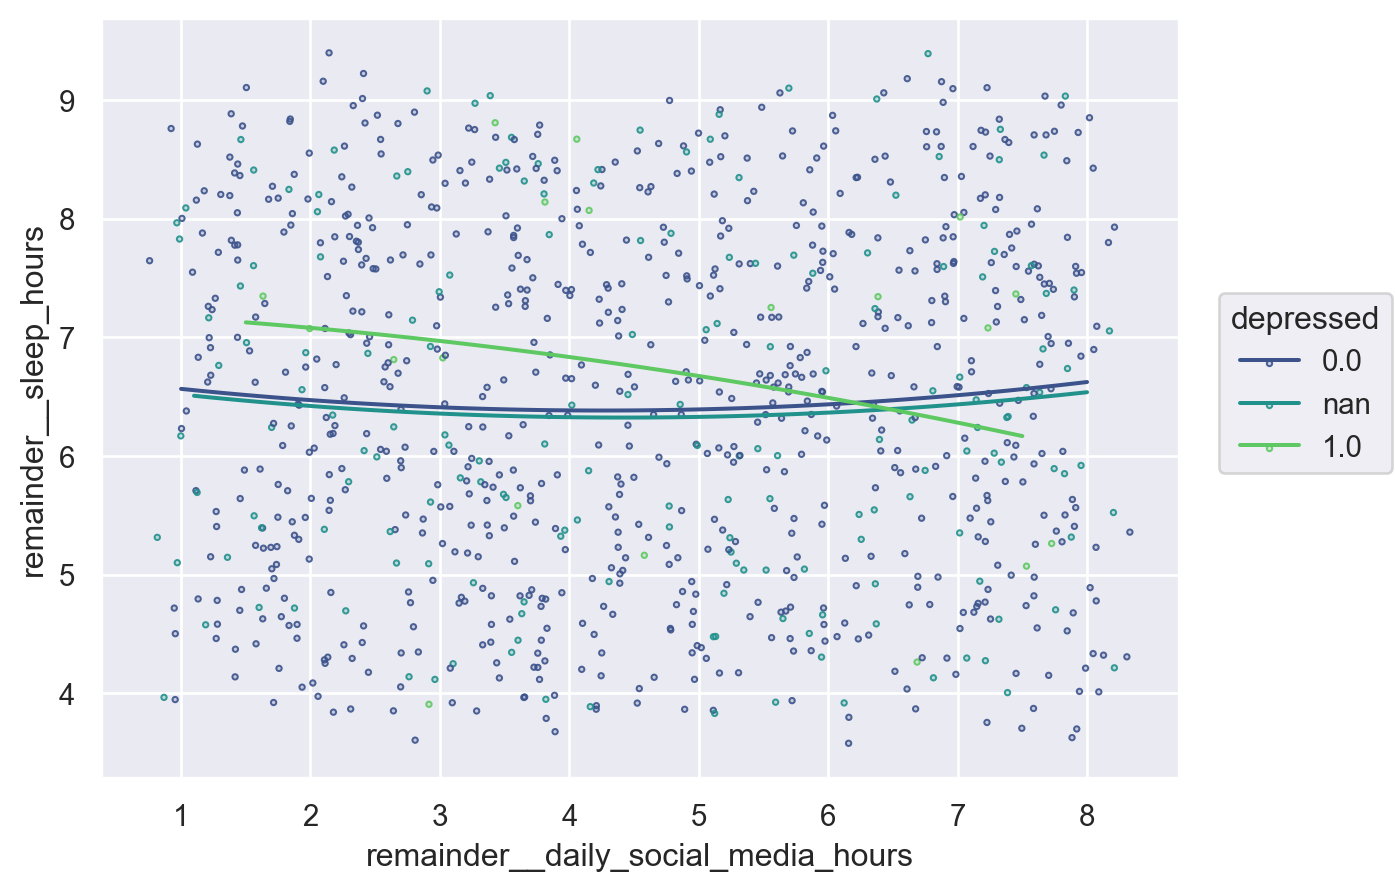

<Figure size 800x400 with 0 Axes>

In [ ]:
import seaborn.objects as so

fig = plt.figure(figsize=(8,4))

so.Plot(z, x='remainder__daily_social_media_hours', y='remainder__sleep_hours',color='depressed')\
  .add(so.Dots(alpha=.9, pointsize=2), so.Jitter(x=.7, y=1))\
  .add(so.Line(), so.PolyFit())\
  .scale(color='viridis')\
  .plot()

In [ ]:
pd.crosstab(index=z.depressed, columns=[z.remainder__daily_social_media_hours, z.remainder__sleep_hours])

remainder__daily_social_media_hours 1.0         1.1                          \
remainder__sleep_hours              4.1 7.1 8.5 5.4 6.4 6.7 7.0 7.1 8.0 8.2   
depressed                                                                     
0.0                                   1   1   1   1   1   1   1   1   1   1   
1.0                                   0   0   0   0   0   0   0   0   0   0   

remainder__daily_social_media_hours  ... 7.9     8.0                          \
remainder__sleep_hours               ... 8.7 8.8 4.3 4.4 4.6 5.4 5.7 6.9 8.1   
depressed                            ...                                       
0.0                                  ...   1   1   1   1   1   1   1   2   1   
1.0                                  ...   0   0   0   0   0   0   0   0   0   

remainder__daily_social_media_hours      
remainder__sleep_hours              8.7  
depressed                                
0.0                                   1  
1.0                                   0  

[2 rows x 698 columns]

In [ ]:
z[z['depressed']==1]['remainder__daily_social_media_hours']

163    2.7
300    6.4
321    1.5
384    4.2
581    7.5
591    4.9
600    7.3
620    4.0
641    1.8
642    2.8
659    6.3
691    3.2
703    7.5
737    3.6
866    7.3
868    6.9
918    5.3
931    3.8
950    3.2
Name: remainder__daily_social_media_hours, dtype: float64

**deeper interactions:**
- you can get interactions with 3 columns from the interaction depth 2 sheet

In [ ]:
pd.read_excel("fir.xlsx", sheet_name="Interaction Depth 2").iloc[:20]\
                                                           .sort_values(by="Average Rank")\
                                                           .head(10)\
                                                           .round(1)

,Interaction,Gain,FScore,wFScore,Average wFScore,Average Gain,Expected Gain,Gain Rank,FScore Rank,wFScore Rank,Avg wFScore Rank,Avg Gain Rank,Expected Gain Rank,Average Rank,Average Tree Index,Average Tree Depth
3,remainder__academic_performance|remainder__dai...,43.1,11,5.1,0.5,3.9,17.1,4,2,1,9,14,3,5.5,14.3,2.5
0,remainder__daily_social_media_hours|remainder_...,66.9,6,2.8,0.5,11.1,22.6,1,11,8,13,2,2,6.2,16.3,2.2
2,cat__gender_female|remainder__daily_social_med...,49.1,5,2.4,0.5,9.8,25.7,3,17,11,7,4,1,7.2,8.8,2.2
4,remainder__academic_performance|remainder__aca...,27.7,11,4.6,0.4,2.5,11.0,5,3,2,20,28,5,10.5,17.8,3.0
11,remainder__academic_performance|remainder__aca...,16.1,9,3.7,0.4,1.8,6.5,12,6,5,21,41,6,15.2,45.0,2.7
9,cat__platform_usage_TikTok|remainder__academic...,17.4,9,3.3,0.4,1.9,6.4,10,5,6,32,40,7,16.7,32.6,3.2
8,remainder__daily_social_media_hours|remainder_...,20.9,9,3.0,0.3,2.3,5.0,9,4,7,46,31,10,17.8,28.7,2.7
5,remainder__daily_social_media_hours|remainder_...,22.1,13,4.4,0.3,1.7,6.0,6,1,3,44,45,8,17.8,37.4,2.4
1,remainder__daily_social_media_hours|remainder_...,59.8,7,1.7,0.2,8.5,12.8,2,8,22,71,5,4,18.7,13.6,3.3
10,cat__gender_female|remainder__daily_social_med...,16.1,2,0.7,0.4,8.1,4.3,11,43,44,41,7,11,26.2,29.5,2.5


In [ ]:
print(pd.read_excel("fir.xlsx", sheet_name="Interaction Depth 2").iloc[:20]\
                                                           .sort_values(by="Average Rank")\
                                                           .head(10)\
                                                           .loc[:,"Interaction"].values)

['remainder__academic_performance|remainder__daily_social_media_hours|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__daily_social_media_hours|remainder__sleep_hours'
 'cat__gender_female|remainder__daily_social_media_hours|remainder__sleep_hours'
 'remainder__academic_performance|remainder__academic_performance|remainder__daily_social_media_hours'
 'remainder__academic_performance|remainder__academic_performance|remainder__sleep_hours'
 'cat__platform_usage_TikTok|remainder__academic_performance|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__screen_time_before_sleep|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__physical_activity|remainder__sleep_hours'
 'remainder__daily_social_media_hours|remainder__daily_social_media_hours|remainder__screen_time_before_sleep'
 'cat__gender_female|remainder__daily_social_media_hours|remainder__daily_social_media_hours']


these interactions lead to insights on how various features relate to each other...

**specifying feature interactions:**
- the xgboost library can limit feature interactions...
- you can specify a list of features that can only be in trees with other limited features

In [ ]:
interactions1 = pd.read_excel("fir.xlsx", sheet_name="Interaction Depth 1").iloc[:20]\
                                                           .sort_values(by="Average Rank")\
                                                           .head(10)\
                                                           .loc[:,"Interaction"].values
interactions1_ = list(map(lambda x: x.split('|'), interactions1))

In [ ]:
interactions1

array(['remainder__daily_social_media_hours|remainder__sleep_hours',
       'remainder__daily_social_media_hours|remainder__daily_social_media_hours',
       'remainder__academic_performance|remainder__daily_social_media_hours',
       'remainder__academic_performance|remainder__sleep_hours',
       'remainder__physical_activity|remainder__sleep_hours',
       'remainder__daily_social_media_hours|remainder__screen_time_before_sleep',
       'remainder__academic_performance|remainder__academic_performance',
       'cat__gender_female|remainder__daily_social_media_hours',
       'cat__gender_female|remainder__sleep_hours',
       'remainder__age|remainder__physical_activity'], dtype=object)

In [ ]:
interactions1_

[['remainder__daily_social_media_hours', 'remainder__sleep_hours'],
 ['remainder__daily_social_media_hours',
  'remainder__daily_social_media_hours'],
 ['remainder__academic_performance', 'remainder__daily_social_media_hours'],
 ['remainder__academic_performance', 'remainder__sleep_hours'],
 ['remainder__physical_activity', 'remainder__sleep_hours'],
 ['remainder__daily_social_media_hours',
  'remainder__screen_time_before_sleep'],
 ['remainder__academic_performance', 'remainder__academic_performance'],
 ['cat__gender_female', 'remainder__daily_social_media_hours'],
 ['cat__gender_female', 'remainder__sleep_hours'],
 ['remainder__age', 'remainder__physical_activity']]

In [ ]:
# filter to only retain the columns in the constraints

def flatten(seq):
    res = []
    for sub in seq:
        res.extend(sub)
    return res

small_cols = sorted(set(flatten(interactions1_)))

In [ ]:
small_cols

['cat__gender_female',
 'remainder__academic_performance',
 'remainder__age',
 'remainder__daily_social_media_hours',
 'remainder__physical_activity',
 'remainder__screen_time_before_sleep',
 'remainder__sleep_hours']

interaction constraints tells xgboost: only alow certain features to appear together inside the same tree path. (it controls which features are allowed to interact)
- with feature interaction constraints, we are strictly laying out the valid combinations and anything outside of this isn't allowed...saves the model from wasting time if relationships/constraints/valid interactions are known

In [ ]:
xg_constraints = xgb.XGBClassifier(interaction_constraints=interactions1_)
xg_constraints.fit(z.loc[:, small_cols], y_train)
xg_constraints.score(pd.DataFrame(x_test_transformed, columns=preprocessing.get_feature_names_out()).loc[:, small_cols], y_test)

0.975

In [ ]:
len(small_cols)

7

In [ ]:
len(z.columns)

15

model does okay when it uses 7 of the 15 features. it doesn't exhibit better performance though than the default ,model.

**Exploring SHAP:**

In [56]:
xtr = pd.DataFrame(x_train_transformed, columns=preprocessing.get_feature_names_out())
xtt = pd.DataFrame(x_test_transformed, columns=preprocessing.get_feature_names_out())

In [57]:
xtt

,cat__platform_usage_Both,cat__platform_usage_Instagram,cat__platform_usage_TikTok,cat__gender_female,cat__gender_male,cat__social_interaction_level_high,cat__social_interaction_level_low,cat__social_interaction_level_medium,remainder__age,remainder__daily_social_media_hours,remainder__sleep_hours,remainder__screen_time_before_sleep,remainder__academic_performance,remainder__physical_activity
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13.0,5.1,5.3,2.6,2.95,1.2
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,17.0,5.3,6.8,1.9,3.39,1.6
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,16.0,4.8,6.7,1.4,2.44,0.3
3,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,18.0,2.5,5.7,2.1,3.33,0.6
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,14.0,2.8,6.2,1.2,3.21,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,13.0,5.5,6.7,1.6,3.09,1.7
236,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,13.0,7.4,6.7,2.0,2.42,1.5
237,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,19.0,1.5,6.8,2.5,2.13,0.2
238,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,19.0,2.8,4.8,1.7,2.80,0.6


In [58]:
xg_step = xgb.XGBClassifier(**best_params, early_stopping_rounds=50, n_estimators=500, objective="binary:logistic")
xg_step.fit(xtr, y_train, eval_set=[(xtr, y_train),(xtt, y_test)])

[0]	validation_0-logloss:0.12060	validation_1-logloss:0.11690
[1]	validation_0-logloss:0.12045	validation_1-logloss:0.11675
[2]	validation_0-logloss:0.12031	validation_1-logloss:0.11662
[3]	validation_0-logloss:0.12031	validation_1-logloss:0.11663
[4]	validation_0-logloss:0.12018	validation_1-logloss:0.11650
[5]	validation_0-logloss:0.11994	validation_1-logloss:0.11626
[6]	validation_0-logloss:0.11985	validation_1-logloss:0.11619
[7]	validation_0-logloss:0.11972	validation_1-logloss:0.11605
[8]	validation_0-logloss:0.11947	validation_1-logloss:0.11582
[9]	validation_0-logloss:0.11933	validation_1-logloss:0.11567
[10]	validation_0-logloss:0.11921	validation_1-logloss:0.11555
[11]	validation_0-logloss:0.11907	validation_1-logloss:0.11540
[12]	validation_0-logloss:0.11894	validation_1-logloss:0.11527
[13]	validation_0-logloss:0.11884	validation_1-logloss:0.11517
[14]	validation_0-logloss:0.11872	validation_1-logloss:0.11504
[15]	validation_0-logloss:0.11847	validation_1-logloss:0.11478
[1

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5203317230460578
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [ ]:
import shap

# enable javascript visualisations:
shap.initjs()

# create an instance of a tree explainer - can provide the shap values for us - tree explainer instance is callable and returns an explanation object
shap_ex = shap.TreeExplainer(xg_step)
# tree explainer can provide shap values for us. the tree explainer instance is callable and returns an explanation object. the object has an attribute .values with the shap valuyes for every feature for each sample
vals = shap_ex(xtt)

In [64]:
vals.base_values.shape

(240,)

In [65]:
vals.values.shape

(240, 14)

shap values:
- how much did this feature push the model output up or down for this specific row | shap values: how much did this feature push the model output up or down for this specific row
  - positive shap value: pushes prediction towards the positive class
  - negative shap value: pushes prediction away from the positive class
- important: what scale are these values on.... for xgboost binary classification, shap often explains the model on the raw margin scale....which means log-odds, not probability
  - log_odds = shap_values.base_values + shap_values.values.sum(axis=1)
  - for each row: model raw output = base value + sum of shap featrue contributions

- row_log_odds = shap_values.base_values[0] + shap_values.values[0].sum()
- the row_log_odds value should match the model's raw prediction -> raw prediction taken from xgb_model.predict(x_test, output_margin=True)
  - for binary classification, xgboost doesn't naturally build probabilities directly | it builds an internal score | that score is a log-odds value | then converts that log-odds into a probability using the sigmoid function....
    - suppose for one row: base_value = -3.0 | before considering the feature values, the model's default prediction is: log_odds = -3.0 | sigmoid(base_value) = 0.047 |
    - adding shap values | shap_for_row = [0.8, -0.2, 1.1, -0.4] | sum of shap = 1.3 | log_odds = -3.0 + 1.3 = -1.7 | sigmoid = 15.4
    - shap values are on the log-odds scale not probability scale | conversion to probability is by taking the sigmoid of shap values

fixed shap error with: pip install "setuptools<82"

In [61]:
shap_df = pd.DataFrame(vals.values, columns = xtt.columns)
shap_df

,cat__platform_usage_Both,cat__platform_usage_Instagram,cat__platform_usage_TikTok,cat__gender_female,cat__gender_male,cat__social_interaction_level_high,cat__social_interaction_level_low,cat__social_interaction_level_medium,remainder__age,remainder__daily_social_media_hours,remainder__sleep_hours,remainder__screen_time_before_sleep,remainder__academic_performance,remainder__physical_activity
0,0.0,0.001126,0.000802,-0.045027,-0.019386,-0.000231,0.000370,-0.005198,0.002952,0.234687,0.603966,-0.004720,0.010411,-0.000157
1,0.0,0.000630,-0.000356,0.031904,0.013113,-0.000231,-0.000942,0.001342,-0.005138,0.299479,-0.731454,-0.000533,0.009895,0.003389
2,0.0,-0.000817,-0.000356,0.027236,0.011610,-0.000231,-0.000372,0.001122,0.002726,-0.464787,-0.570939,0.002780,-0.011527,-0.002124
3,0.0,0.001126,-0.000356,-0.038905,-0.017416,-0.000231,-0.000372,0.002762,-0.005522,-0.627804,0.440727,0.002037,0.009787,-0.005201
4,0.0,0.000485,-0.000356,-0.025255,-0.010930,-0.000231,-0.000372,0.001122,0.001419,-0.470693,-0.542777,0.001266,0.006433,-0.001568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,0.0,0.000630,-0.000356,0.032334,0.013103,0.000482,0.000370,0.001342,0.001869,0.300751,-0.733784,0.000608,0.009644,0.003537
236,0.0,0.000630,-0.000356,0.033234,0.012622,-0.000231,-0.000942,0.001342,0.001967,0.517025,-0.727083,0.000302,-0.017777,0.003537
237,0.0,0.000485,0.000802,-0.023997,-0.010543,-0.000231,0.000146,-0.001958,-0.002888,-0.461279,-0.529831,-0.001452,-0.011696,-0.002306
238,0.0,0.001126,0.000802,0.042856,0.019102,-0.000231,-0.000372,0.002762,-0.005842,-0.644416,0.543245,-0.001045,0.003021,-0.005019


if u add up each row and add the .base_values attribute (default guess for the model) - u get the log odds that the sample is in the positive class.

further analysis...

In [67]:
shap_df.sum(axis=1).rename('pred')

0      0.779596
1     -0.378901
2     -1.005679
3     -0.239367
4     -1.041458
         ...   
235   -0.369472
236   -0.175729
237   -1.044747
238   -0.044011
239   -1.037458
Name: pred, Length: 240, dtype: float32

In [82]:
y_test

673    0
570    0
493    0
837    0
927    0
      ..
576    0
911    0
392    0
221    0
349    0
Name: depression_label, Length: 240, dtype: int64

In [84]:
pd.concat([
    (shap_df.sum(axis=1).rename('pred') + vals.base_values).reset_index(drop=True),
    pd.Series(y_test, name='true').reset_index(drop=True)
], axis=1).assign(prob = lambda adf : (np.exp(adf.pred))/(1+np.exp(adf.pred)))

,pred,true,prob
0,-2.827802,0,0.055840
1,-3.986300,0,0.018230
2,-4.613077,0,0.009824
3,-3.846766,0,0.020902
4,-4.648856,0,0.009482
...,...,...,...
235,-3.976871,0,0.018399
236,-3.783128,0,0.022245
237,-4.652145,0,0.009451
238,-3.651409,0,0.025298


In [85]:
shap_analysis = pd.concat([
    (shap_df.sum(axis=1).rename('pred') + vals.base_values).reset_index(drop=True),
    pd.Series(y_test, name='true').reset_index(drop=True)
], axis=1).assign(prob = lambda adf : (np.exp(adf.pred))/(1+np.exp(adf.pred)))

In [88]:
shap_analysis[shap_analysis['true'] == 1]

,pred,true,prob
46,-2.549177,1,0.072482
102,-2.451651,1,0.079318
155,-2.403324,1,0.082920
168,-2.661595,1,0.065278
170,-2.803718,1,0.057124
223,-2.525537,1,0.074087


model makes incorrect preds for the above values..

**Examining a single prediction:**
- to explore how shap attributes the prediction from the features, you can create a few visualisations...

In [89]:
xtt.iloc[0]

cat__platform_usage_Both                 0.00
cat__platform_usage_Instagram            0.00
cat__platform_usage_TikTok               1.00
cat__gender_female                       0.00
cat__gender_male                         1.00
cat__social_interaction_level_high       0.00
cat__social_interaction_level_low        0.00
cat__social_interaction_level_medium     1.00
remainder__age                          13.00
remainder__daily_social_media_hours      5.10
remainder__sleep_hours                   5.30
remainder__screen_time_before_sleep      2.60
remainder__academic_performance          2.95
remainder__physical_activity             1.20
Name: 0, dtype: float64

In [90]:
xg_step.predict(xtt.iloc[[0]])

array([0])

In [93]:
y_test.iloc[0]

0

In [95]:
shap_ex.expected_value

-3.6073983

default is 0 - not depressed...
- then we add the sum of the shap values

In [96]:
shap_ex.expected_value + vals.values[0].sum()

-2.8278024

below 0 so still predict 0 class

**waterfall plots:**
- plots an explanation of a single prediction | displays how the shap value from each column impacts the result. 

**SHAP values break the model’s output into per-feature contributions, showing how each feature pushes an individual prediction away from the model’s baseline/default prediction.**

<Axes: >

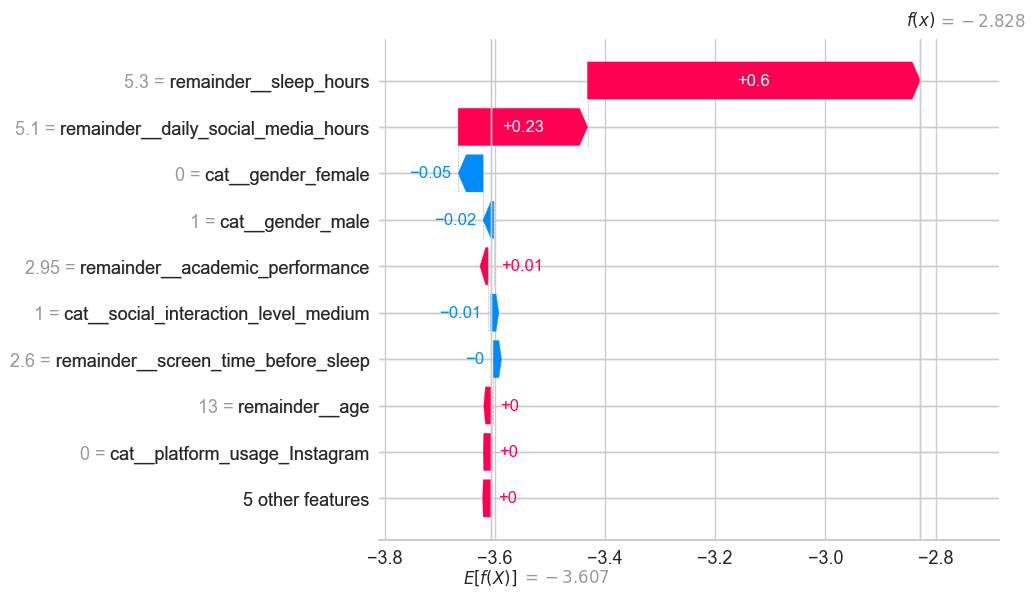

In [97]:
# shap values for first pred to see what impacted it
fig = plt.figure(figsize=(8,4))
shap.plots.waterfall(vals[0], show=False)

above model has a very low expected value....very biased towards the negative class.
- meaning on average based on reference data..it has an average pred of -3.607

In [104]:
np.exp(-3.607)/(1+np.exp(-3.607))

0.026416365728228322

got to overcome the above probability first before hitting zero

In [99]:
(y_train == 0).sum(), (y_train == 1).sum()

(935, 25)

model's expected value is at -3.6...heavily skewed towards the negative (not depressed class) - because of the huge class imbalance in this case.
- more on shap
  - think of shap as trying to answer this: "starting from the model's average/default prediction, how much does each feature move this specific row's prediction up or down?"
  - so, the decomposition basically is:
    - f(x) = E[f(X)] + phi1 + phi2 + phi3 + .... + phip
    - where f(x) => model output for this specific row
   - E[f(X)] => expected/base value/default prediction
   - phi_j => shap value for feature j
  - what is the shap expected value: the expected value is the model's average output over some background data....
    - conceptually: E[f(X)]: what does the model predict before knowing anything
      - code: explainer = shap.Explainer(xgb_model, X_train) | shap_values = explainer(X_test)
      - shap asks: across the background data, whats the model's average output: explainer.expected_value | for bina
    - Shap base values: 
      - modern shap: shap_values.base_values is basically the expected value attached to each sample...

In [100]:
shap_ex.expected_value

-3.6073983

In [103]:
vals.base_values

array([-3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073983,
       -3.6073983, -3.6073983, -3.6073983, -3.6073983, -3.6073

as seen above, the base_values and the expected values are the same...they come from the background/reference dataset you give to shap and from the model outputs on that dataset. (shap expected value is the model's defaylt/average prediction before looking at the specific row being explained....)
- expectd value is the raw average model output on the background data, i.e. the E[f(x)]
- then the shap values are the raw scores showing the impact of that feature on the overall output

to get a feel for how the values of this sample relate to other samples, we can plot a histogram showing the distributions of the values and mark our value...

In [109]:
def plot_histograms(df, columns, row=None, title='', color='shap'):
    """
        Parameters:
         df: pandas.DataFrame -> the dataframe to plot_histograms for

         columns: list of str

         row: row of data to plot vertical line for

         title: title for figure

         color: shap - color positive values red, negative blue | mean - above mean red, below blue | None - black

         Returns: matplotlib figure
    """
    red = '#ff0051'
    blue = '#008bfb'

    fig, ax = plt.subplots(figsize=(10,5))
    hist = (df[columns].hist(ax=ax, color='#bbb'))

    fig = hist[0][0].get_figure()

    if row is not None:
        name2ax = {ax.get_title():ax for ax in fig.axes}
        pos,neg = red, blue
        if color is None:
            pos, neg = 'black', 'black'
        
        for column in columns:
            if color == 'mean':
                mid = df[column].mean()
            else:
                mid = 0
            if row[column] > mid:
                c = pos
            else:
                c = neg
            name2ax[column].axvline(row[column], c=c)
    fig.tight_layout()
    fig.suptitle(title)
    return fig

In [110]:
xtr.columns

Index(['cat__platform_usage_Both', 'cat__platform_usage_Instagram',
       'cat__platform_usage_TikTok', 'cat__gender_female', 'cat__gender_male',
       'cat__social_interaction_level_high',
       'cat__social_interaction_level_low',
       'cat__social_interaction_level_medium', 'remainder__age',
       'remainder__daily_social_media_hours', 'remainder__sleep_hours',
       'remainder__screen_time_before_sleep',
       'remainder__academic_performance', 'remainder__physical_activity'],
      dtype='str')

/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_20940/339340974.py:20: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.


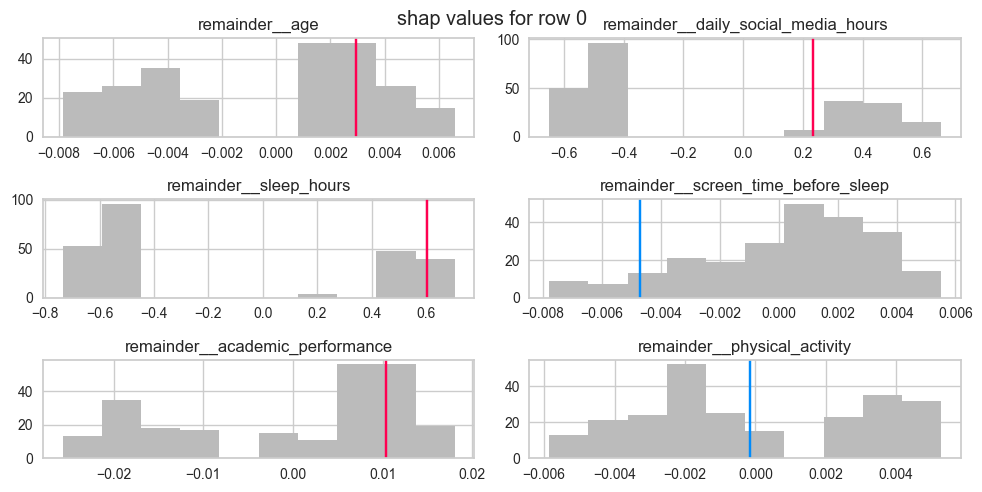

In [111]:
features = ['remainder__age', 'remainder__daily_social_media_hours', 'remainder__sleep_hours', 'remainder__screen_time_before_sleep', 'remainder__academic_performance', 'remainder__physical_activity']

fig = plot_histograms(shap_df, features, shap_df.iloc[0], title='shap values for row 0')
fig

we can also use this function to visualise the histogram of the original feature values...

/var/folders/_h/yzv4_kzj2yv3z5xh7lks3hpr0000gn/T/ipykernel_20940/339340974.py:20: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.


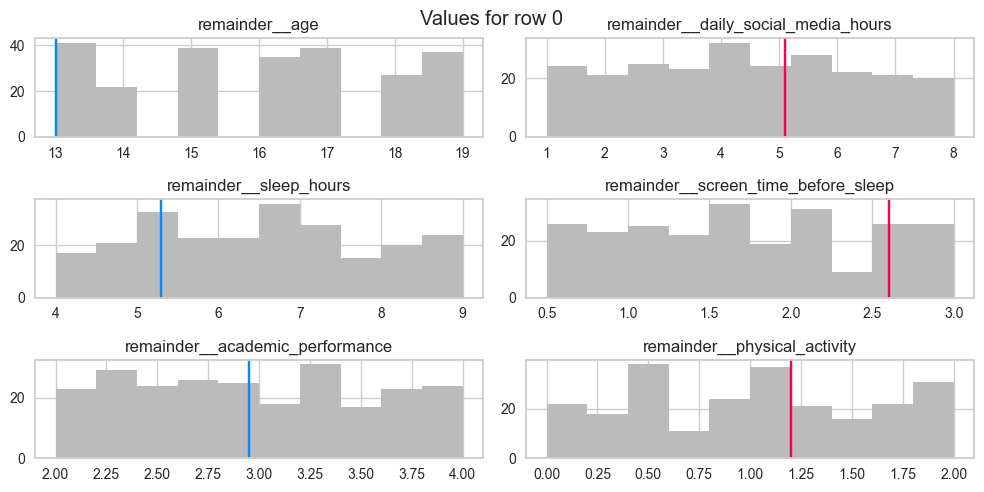

In [112]:
fig = plot_histograms(xtt, features, xtt.iloc[0], title='Values for row 0', color='mean')
fig

can also create a bar plot of the shap values with the pandas library:

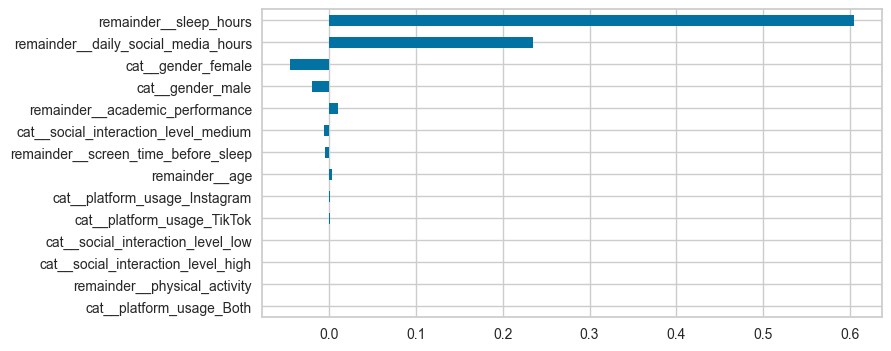

In [116]:
fig, ax = plt.subplots(figsize=(8,4))
pd.Series(vals.values[0], index=xtt.columns).sort_values(key=np.abs).plot.barh(ax=ax)
fig

**force plot:**
- the shap library also provides a flattened version of the waterfall plot, called the force plot. 

In [120]:
res = shap.plots.force(base_value = vals.base_values, shap_values=vals.values[0,:],features=xtt.iloc[0], matplotlib=False,show=True)
res

In [122]:
shap.plots.force(base_value = vals.base_values, shap_values=vals.values[0,:],features=xtt.iloc[0], matplotlib=False,show=True)

force plot with multiple predictions:
- the shap library allows you to pass in multiple rows of shap values into the force function. 

In [121]:
# first 100 values
n = 100

shap.plots.force(base_value=vals.base_values, 
                 shap_values=vals.values[:n,:],
                 features=xtt.iloc[:n])

above is a force plot using shap values for the first 100 examples from oput test set.
- on the y axis => we have the log_probs values (model's raw outputs before getting converted to probabilities with: np.exp(val)/(1 + np.exp(val)))
- on the x axis => we have individual examples....
- javascript interactivity is left on, so, we can hover over the preds, to see for a particular example, what features contributed to its predictions

**understanding feature dependence plots:**
- because the shap library has computed shap values for every feature, we can use that to visualise how features impact the model
- the dependence scatter plot shows the shap values across the values for a feature

picking one feature that has had a big impact on our model - daily social media hours....

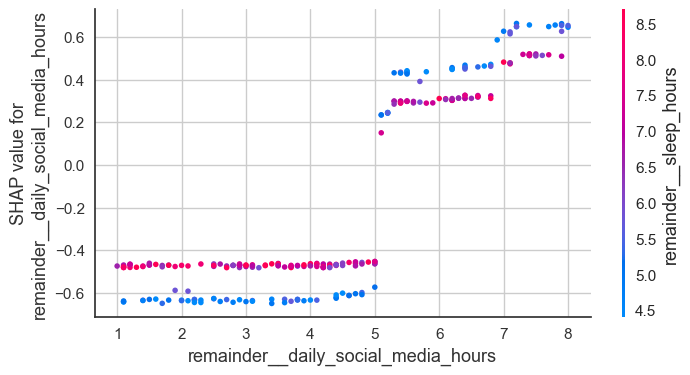

In [125]:
fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:, 'remainder__daily_social_media_hours'], ax=ax, color=vals, x_jitter=0, hist=False)

making sense of the above plot:
- on the x-axis: different entries for daily_social_media_hours
- on the y-axis: different shap values for each of the social media hours ...adds another y axis to show the other attribute frequently interacted with the daily_social_media_hours
- linear relationship between social meda hours and target, remember shap value > 0 will push the final model output to the positive class...we can see that for social media hours > 5, the push is generally towards the positive class
- shap library automatically chosen the sleep_hours interaction column here allowing us to visualise the impact of another column..
- can see that the less the sleep hoirs, the more the push towards the positive class though not so obvious/direct
- can specify a different column by setting the color parameter to a single column of values (color=vals[:,'col x'])

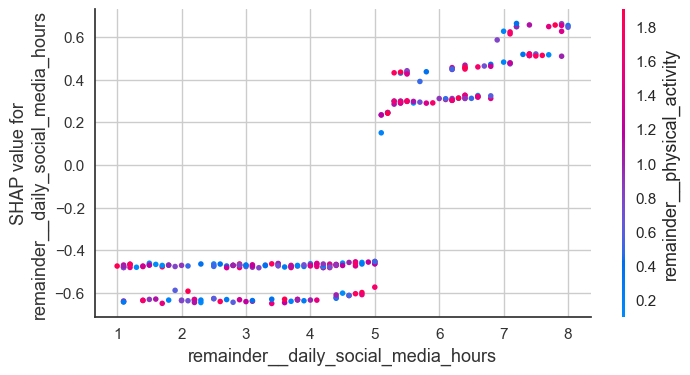

In [ ]:
# switching the interaction column/attribute

fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:, 'remainder__daily_social_media_hours'], ax=ax, color=vals[:, 'remainder__physical_activity'], x_jitter=0, hist=False)

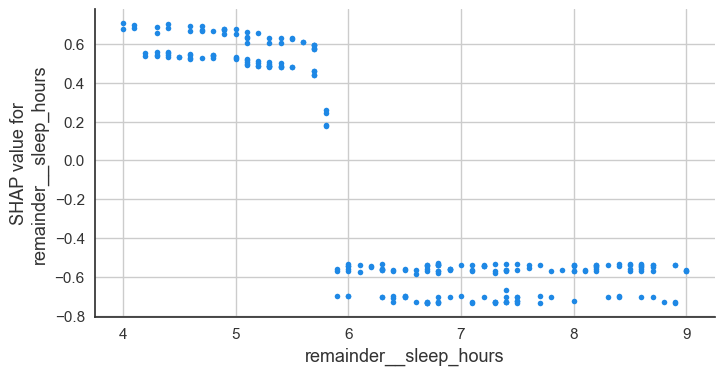

In [131]:
fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:, 'remainder__sleep_hours'], ax=ax, x_jitter=0, hist=False)

fewer the sleep hours, the higher the chance for predicting class 1, and the reverse is true..

**Jittering a dependence plot:**
- to spread the values and improve visibility, we make use of the x_jitter param. and alpha for visibility. by default, every dot has a transparency of 1 => implying its opaque...

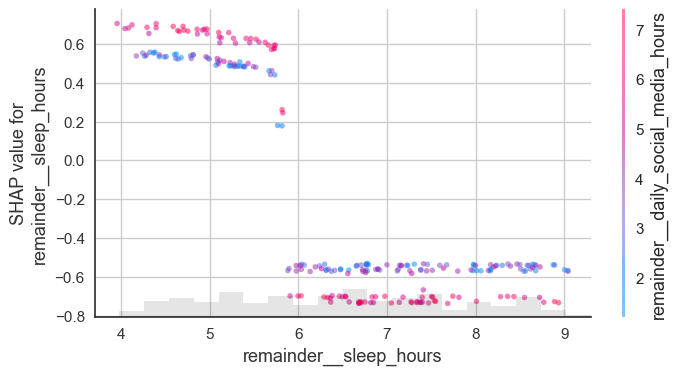

In [133]:
fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:,'remainder__sleep_hours'], ax=ax, color=vals[:, 'remainder__daily_social_media_hours'], x_jitter=1, alpha=0.5)

**Heatmaps and correlations:**
- can be useful to look at the heatmaps of correlations of shap values
- starting with the standard correlation of the features (not involving shap)

In [134]:
import seaborn as sns

In [136]:
xtt.columns

Index(['cat__platform_usage_Both', 'cat__platform_usage_Instagram',
       'cat__platform_usage_TikTok', 'cat__gender_female', 'cat__gender_male',
       'cat__social_interaction_level_high',
       'cat__social_interaction_level_low',
       'cat__social_interaction_level_medium', 'remainder__age',
       'remainder__daily_social_media_hours', 'remainder__sleep_hours',
       'remainder__screen_time_before_sleep',
       'remainder__academic_performance', 'remainder__physical_activity'],
      dtype='str')

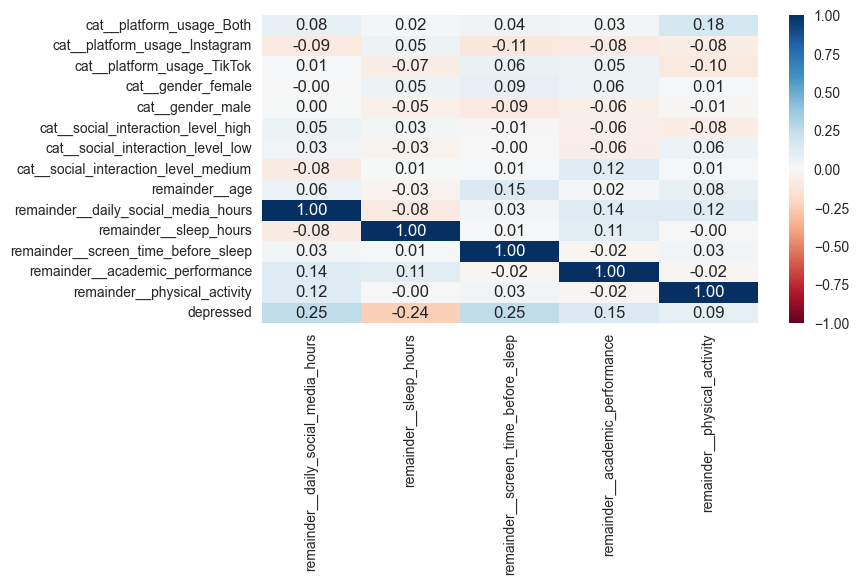

In [139]:
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(xtt.assign(depressed=y_test).corr(method='spearman').loc[:,['remainder__daily_social_media_hours','remainder__sleep_hours','remainder__screen_time_before_sleep','remainder__academic_performance', 'remainder__physical_activity']],\
            cmap='RdBu', annot=True, fmt='.2f', vmin=-1, vmax=1, ax=ax)
fig

above correlation tells us if the features tend to move in the same or opposite directions
- the target pred is added as well to show the correlation between that and the features as well

next, we create a heatmap of the correlation of the shap values for each prediction. the correlation will tell us if 2 features tend to move the prediction similarly.

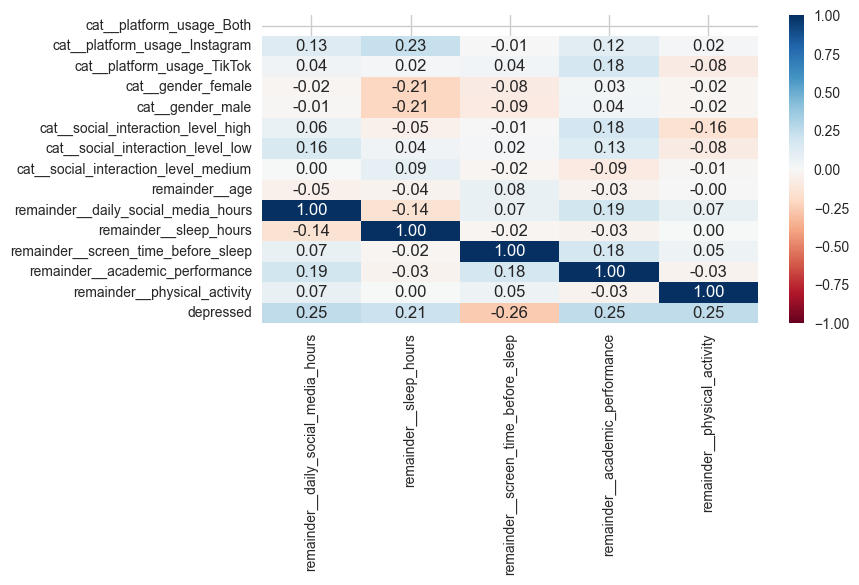

In [140]:
fig, ax = plt.subplots(figsize=(8,4))
sns.heatmap(shap_df.assign(depressed=y_test).corr(method='spearman').loc[:,['remainder__daily_social_media_hours','remainder__sleep_hours','remainder__screen_time_before_sleep','remainder__academic_performance', 'remainder__physical_activity']],\
            cmap='RdBu', annot=True, fmt='.2f', vmin=-1, vmax=1, ax=ax)
fig

correlation:
- inspecting dark read and dark blue values 
- shap values for daily social media hours tend to rise if shap values for platform usage instagram rise..as well as those of academic performance

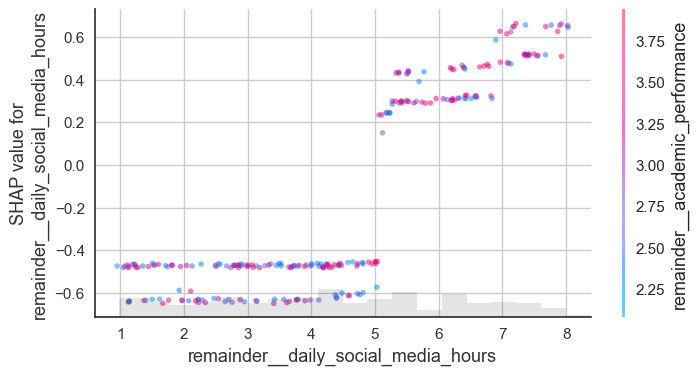

In [144]:
fig, ax2 = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:,'remainder__daily_social_media_hours'], ax=ax2, color=vals[:, 'remainder__academic_performance'], x_jitter=2, alpha=0.5)

**Beeswarm plots of global behaviour:**
- one of the reasons that SHAP is popular is that it not only explains local predictions and feature interactions, but, it also gives you a global view of how features impact the model
  - lets look at the beeswarm or summary plot
  - this provides a rank-ordered listing of the features that drive tge most impact on the final prediction
    - in the x-axis is the shap value
    - positive values push towards the positive label
    - each feature is colired to indicate high (red) or low (blue) values | colors are the raw feature values | high value: red and low value: blue

  - the spread on the red values indicates some interaction with other columns. another way to understand this is that there are probably some low frequency effects when the color is a particular value that cause a large impact on the model

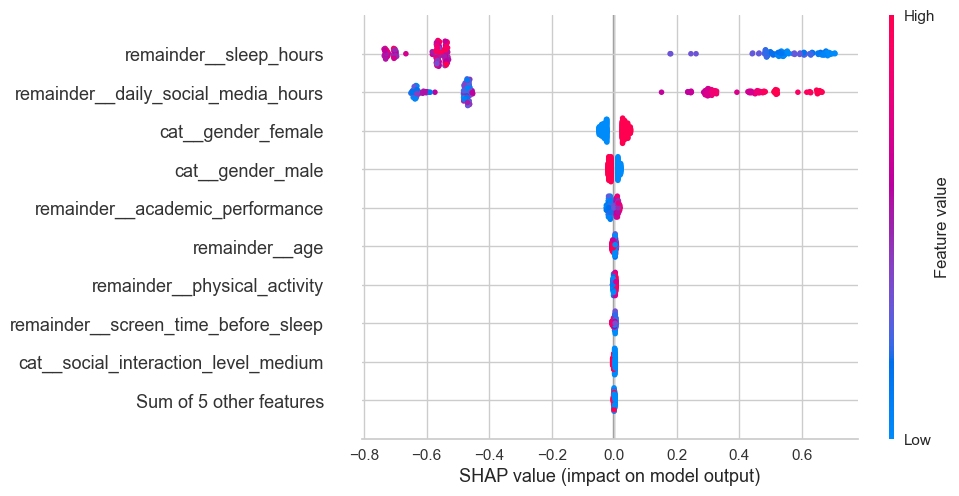

In [145]:
fig = plt.figure(figsize=(8,4))
shap.plots.beeswarm(vals)

beeswarm plot:
- top down.. shows the most influcential features in order. | ranking comes from mean absolute SHAP values | sleep hours is the feature whose values most strongly move predictions away from the baseline on average
  - low sleep hours, pushes the model up to make positive predictions and vice versa | the effect is large, roughly from about -0.8 to0.6 shap
- mixed colors on both sides of the SHAP plot would indicate tjat that feature relies on interactions with other features and isn't standing on its own
- wide row: like for sleep hours and social media hours means its a strong feature..narrow rows mean weak feature
- narrow features might still matter for some rows/records but general consensus is the narrower it gets, the less important it is

interpretation of above beeswarm plot:
- from the above plot: low values(blue) of sleep hours -> push towards positive predictions
- high values(red) of daily social media hours push towards positive predictions
  - values are spread showing interaction with other features | or spread showing some high freq or low freq value leading to that prediction

to see all features, we use the max_display parameter.

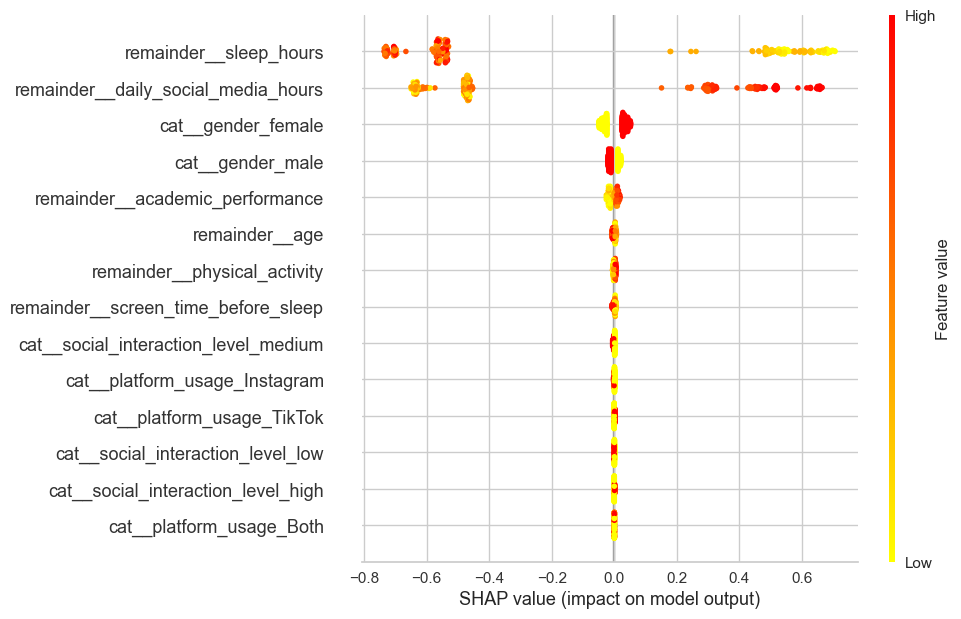

In [146]:
from matplotlib import cm

fig = plt.figure(figsize=(8,4))
shap.plots.beeswarm(vals, max_display=len(xtt.columns), color=cm.autumn_r)

initially, we used xgboost's raw feature importance functions to investigate feature importances...
- crude mechanism now, considering shap
- whilst feature importances is useful, it doesn't show:
  - whether the feature pushes predictions up or down
  - whether high values increase or decrease prediction
  - whether the feature effect is consistent or only affects a few rows
  - whether there are weird outliers
  - how feature values relate to prediction direction

- SHAP beeswarm answers:
  - across all rows, how much did each feature actually push individual predictions up or down
  - each dot is one row/sample

**SHAP with no interaction:**
- if a model has interactions, shap will reflect them. if we remove interactions, we simplify tge model (max_depth of 1). it also makes non-linear responses more clear

In [147]:
# train a model of stumps and look at the SHAP plots
no_int_params = {
    'random_state': 42,
    'max_depth': 1
    }
xg_no_int = xgb.XGBClassifier(**no_int_params, early_stopping_rounds=50, n_estimators=500)
xg_no_int.fit(xtr, y_train, eval_set=[(xtr, y_train), (xtt, y_test)])

[0]	validation_0-logloss:0.11077	validation_1-logloss:0.10728
[1]	validation_0-logloss:0.10250	validation_1-logloss:0.09908
[2]	validation_0-logloss:0.09763	validation_1-logloss:0.09462
[3]	validation_0-logloss:0.09309	validation_1-logloss:0.09028
[4]	validation_0-logloss:0.08980	validation_1-logloss:0.09060
[5]	validation_0-logloss:0.08661	validation_1-logloss:0.08790
[6]	validation_0-logloss:0.08413	validation_1-logloss:0.08554
[7]	validation_0-logloss:0.08196	validation_1-logloss:0.08379
[8]	validation_0-logloss:0.08021	validation_1-logloss:0.08219
[9]	validation_0-logloss:0.07867	validation_1-logloss:0.08101
[10]	validation_0-logloss:0.07742	validation_1-logloss:0.07989
[11]	validation_0-logloss:0.07630	validation_1-logloss:0.07906
[12]	validation_0-logloss:0.07538	validation_1-logloss:0.07979
[13]	validation_0-logloss:0.07455	validation_1-logloss:0.08121
[14]	validation_0-logloss:0.07371	validation_1-logloss:0.08059
[15]	validation_0-logloss:0.07297	validation_1-logloss:0.08002
[1

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [148]:
xg_no_int.score(xtt, y_test)

0.975

**stump model shap analysis:**

In [149]:
shap_ind = shap.TreeExplainer(xg_no_int)
shap_ind_vals = shap_ind(xtt)

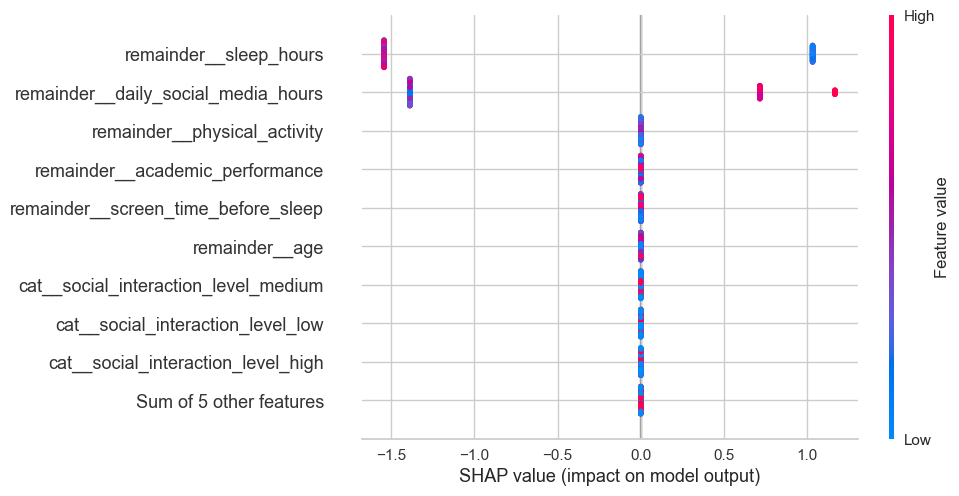

In [150]:
# summary plot with no interactions:
fig = plt.figure(figsize=(8,4))
shap.plots.beeswarm(shap_ind_vals)

no variation on the x-axis on the above plot..showing no interactions with other columns.. | y_axis one is due to jittering

- interesting to note that with interactions removed, the ordering of feature importances changes 
- picking up a feature and explaining it more:

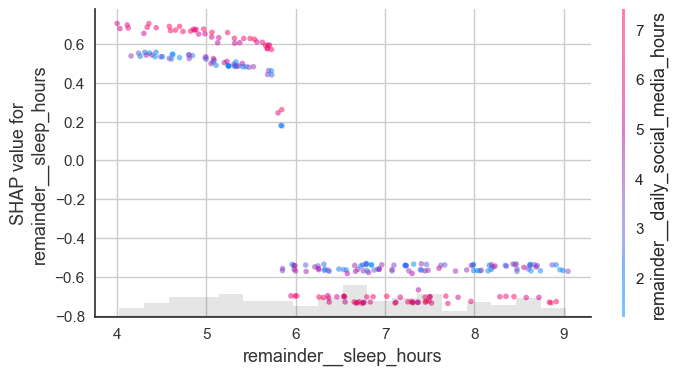

In [151]:
# original model with interactions - the sleep hours feature
fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(vals[:,'remainder__sleep_hours'], ax=ax, color=vals[:, 'remainder__daily_social_media_hours'], alpha=0.5, x_jitter=1)

- vertical spread is due to the interaction with other columns | spread in the x-axis is due to jittering

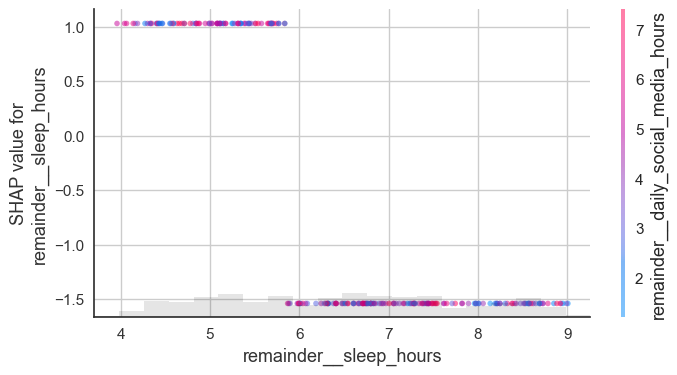

In [152]:
# comparing that with a model with no interactions:
fig, ax = plt.subplots(figsize=(8,4))
shap.plots.scatter(shap_ind_vals[:,'remainder__sleep_hours'], ax=ax, color=shap_ind_vals[:, 'remainder__daily_social_media_hours'], alpha=0.5, x_jitter=1)

no variation on the y - axis hence no interactions with other columns...making perfect sense as its a model of stumps

**summary:**
- SHAP -> POWERFUL TOOL 

**Better Models with ICE, Partial Dependence, Monotonic Constraints, and Calibration**
- **ICE Plots:**
  - Individual Conditional Expectation (ICE) plots are useful for visualising the effect of a single input variable on the outcome of a machine learning model
  - help us understand how each feature contributes to the final predictions made by the model. 
  - An ICE plot shows the predicted values of a machine learning model for a single observation as the values for a specific input feature varies
  - An ICE plot displays the model's output for a fixed instance while incrementally changing one input feature's value | each line  in the plot represents the predicted output for a particular instance as the input feature changes.
  - By examining the shape and slope of each line, we can gain insights into how the model uses that input feature to make predictions.


  ----------------------------
- ICE plot:
  - choose an input feature to analyze and select a range of values for that feature to vary
  - fix the values of all other input features to the observed values for the instance of interest
  - vary the selected input feature across the values
  - for each value of the selected input feature, calculate the corresponding prediction of the model for the specific instance of interest
  - plot

In [153]:
xgb_def = xgb.XGBClassifier(random_state=42)
xgb_def.fit(xtr, y_train)
xgb_def.score(xtt, y_test)

0.975

In [154]:
from sklearn.inspection import PartialDependenceDisplay

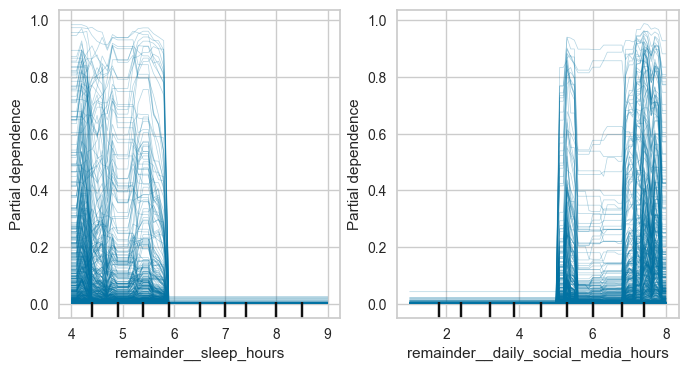

In [157]:
fig, axes = plt.subplots(ncols=2, figsize=(8,4))
PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__sleep_hours', 'remainder__daily_social_media_hours'], kind="individual", ax=axes)
fig

y-axes represent the probability of the final label - "depressed" in this case......e.g. if sleep hours decreases, there's a strong push towards the label 1.0 (depressed) - reverse is true for daily social media hours...

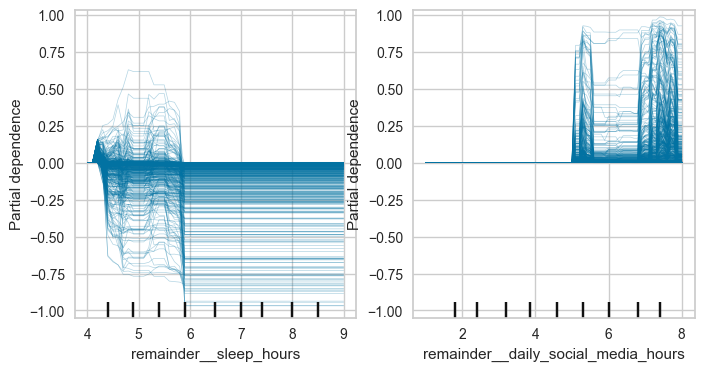

In [159]:
# to make this viz clearer, we can use the centered parameter
fig, axes = plt.subplots(ncols=2, figsize=(8,4))
PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__sleep_hours', 'remainder__daily_social_media_hours'], centered=True, kind='individual', ax=axes)
fig

from the above plot...for sleep hours, clearly some where low sleep hours still results in not being depressed...whereas for others..low sleep hours results in getting depressed...
- social media hours is a good feature...increase in it results in getting depressed

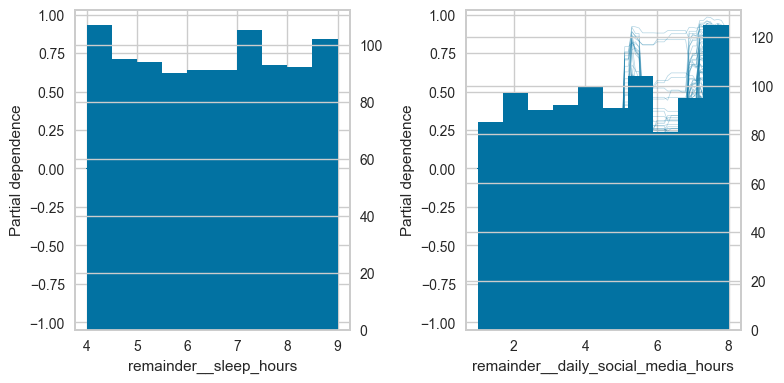

In [161]:
# adding a histogram to show the distribution of the data
fig, axes = plt.subplots(ncols=2, figsize=(8,4))
ax_h0 = axes[0].twinx()
ax_h0.hist(xtr.remainder__sleep_hours, zorder=0)

ax_h1 = axes[1].twinx()
ax_h1.hist(xtr.remainder__daily_social_media_hours, zorder=0)

PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__sleep_hours', 'remainder__daily_social_media_hours'], centered=True, kind='individual', ax=axes, ice_lines_kw={'zorder':10})

fig.tight_layout()
fig

**ICE Plots with SHAP:**
- can get the shap library to plot the ice plot as well....
  - model parameter needs to be a function that, given rows of data, will return probabilities
  - can specify the rows to draw ice lines using the data parameter
  - need to ensure that the npoints param is the number of unique values for a column

In [162]:
import shap

In [164]:
fig, ax = plt.subplots(figsize=(8,4))

shap.plots.partial_dependence_plot(ind='remainder__sleep_hours', model=lambda rows: xgb_def.predict_proba(rows)[:, -1],\
                                   data = xtr.iloc[0:1000], ice=True, npoints=(xtr.remainder__sleep_hours.nunique()), pd_linewidth=0, show=False, ax=ax)

ax.set_title('ICE plot (from SHAP)') 

AttributeError: module 'shap.plots' has no attribute 'partial_dependence_plot'

Partial Dependence Plots (PDPs):
- average of an ICE plot

PDPs are a popular viz in ML to understand the relationship between input variables and the model's predicted output. PDPs illustrate the average behaviour of the model for a particular input variable whilst holding all other variables constant. these plots allow us to identify non-linear r/os, interactions, and other important patterns in the data not immediately apparent from summary stats or simple scatterplots.

averaged ice plot:

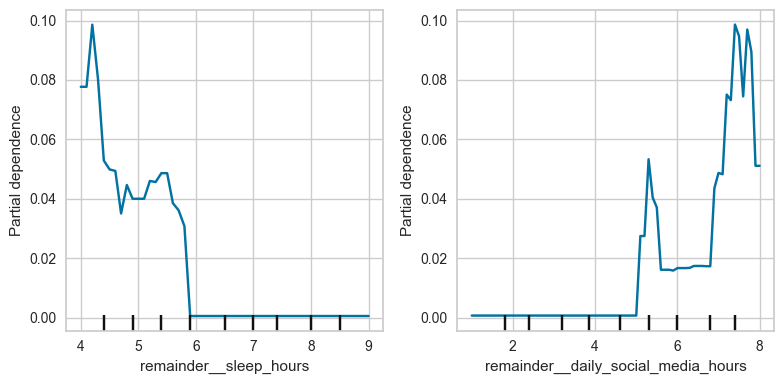

In [166]:
fig, axes = plt.subplots(ncols=2, figsize=(8,4))
PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__sleep_hours', 'remainder__daily_social_media_hours'],
kind='average', ax=axes)
fig.tight_layout()
fig

common suggestion is to plot the PDP plot on top of a centered ICE plot. 

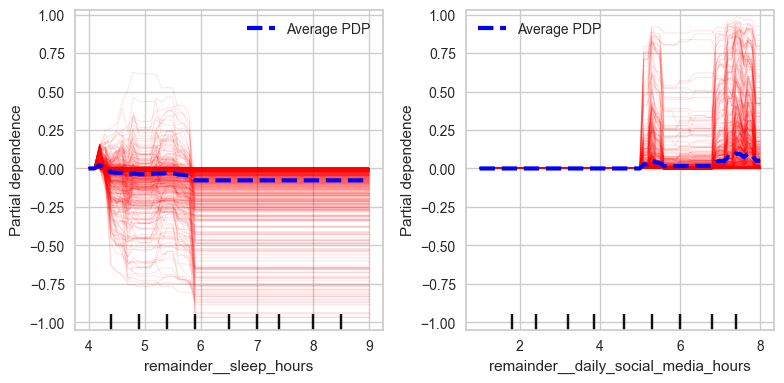

In [172]:
fig, axes = plt.subplots(ncols=2, figsize=(8,4))

PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__sleep_hours', 'remainder__daily_social_media_hours'],
kind='both', ax=axes, centered=True, 
line_kw={
        "color": "blue",
        "linewidth": 3,
        "label": "Average PDP"
    },
    ice_lines_kw={
        'color':'red',
        "alpha": 0.1,
        "linewidth": 0.8
    })
fig.tight_layout()
fig

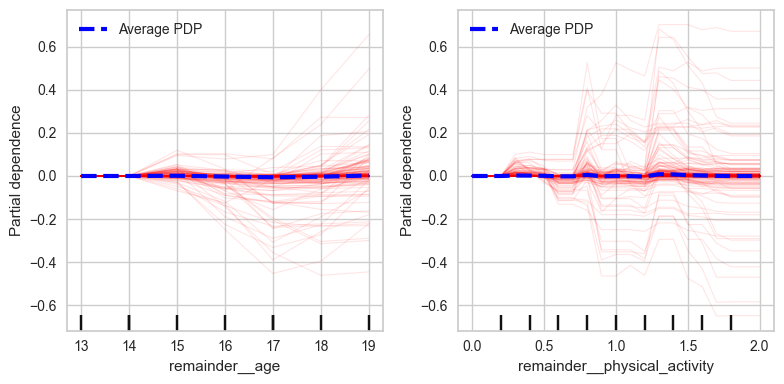

In [176]:
fig, axes = plt.subplots(ncols=2, figsize=(8,4))

PartialDependenceDisplay.from_estimator(xgb_def, xtr, features=['remainder__age', 'remainder__physical_activity'],
kind='both', ax=axes, centered=True, 
line_kw={
        "color": "blue",
        "linewidth": 3,
        "label": "Average PDP"
    },
    ice_lines_kw={
        'color':'red',
        "alpha": 0.1,
        "linewidth": 0.8
    })
fig.tight_layout()
fig

y-axis remember is the model's predicted probability...

PDP plots for age and physical activity are mostly flat, with some spread in the ICE values:
- indicating that there's probably some interaction with other columns | on average the features have little effect but for individual samples, it may still affect predictions
- beeswarm plot however shows this interaction is minimal | shap values for these features mainly centered around zero showing and further confirming the interaction only affects a small group and positive and negative effects cancel 
- can't discard the features entirely though...because looking at the magnitude of ice plots...averages go up to 0.6....thats a significant swing

**Monotonic Constraints:**
- monotonic constraints => r/os between a feature and a target value (direct r/os) and can sometimes be examined with a correlation plot
- for cases/times where we are sure about a particular monotonic relationship between a feature and outcome, we can add this constraint to the model
- a monotonic constraint can be added to ensure the model adheres to a particular relationship between a feature and an outcome
  - Monotonic constraints: tell XGBoost for this feature, as its value increases, the model prediction must only move in one allowed direction
  - can force a feature to have: +1 = increasing relationship | -1 = decreasing relationship | 0 = unconstrained
  - e.g. with an increasing monotonic constraint on a particular feature, xgboost restricts tree splits and leaf values so the final ensemble respects the constraint

- why monotonic constraints matter:
  - stop the model learning nonsense wiggles (e.g. wiggles like salary increases with experience up to 5 years, then drops between 5 to 8 years then rises again - clear pattern its overfitting to getting picked up from the training dataset)
  - make the model more explainable: 
  - improves generalisation: if the domain belief is correct: the constraint then reduces the model's search space | instead of allowing all possible relationships, xgboost is forced to search only relationships consistent with the prior belief | this can in turn reduce overfitting | 

In [175]:
xgb_const = xgb.XGBClassifier(random_state=42, monotone_constraints={'remainder__sleep_hours':-1, 'remainder__daily_social_media_hours':1})
xgb_const.fit(xtr, y_train)
xgb_const.score(xtt, y_test)

0.9708333333333333

performance improves with the added monotonic constraints..